# M8 Pipeline — Pool-Anchored Huber Regression with Conformal Prediction Intervals

**Dataset:** MCC 5411 (Grocery Stores) · monthly `avg_proc_cost_pct` per merchant  
**Task:** Predict a new merchant's processing cost % for months t+1, t+2, t+3, given 1 month of context.

**Key design principle — "new merchant" framing:**  
The model never uses the target merchant's own history. All features and prediction intervals  
are derived from peer merchants only, making the pipeline applicable to merchants with no prior history.

| Section | Content |
|---|---|
| 1–3 | Imports, data, helper functions |
| 4–5 | Scenario generation, merchant-level 60/20/20 split |
| 6–7 | Pool mean feature, rolling temporal CV (architecture validation) |
| 8 | Final model fit + conformal calibration |
| 9 | End-to-end evaluation |
| 10 | Coverage level sweep |


## 1. Imports

In [1]:
import os
import math
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# ── Pipeline configuration ────────────────────────────────────────────────────
CONTEXT_LEN = 6   # number of observed months fed as input to the model
HORIZON_LEN = 3   # number of months to forecast (t+1 … t+HORIZON_LEN)

# Conformal / k-NN constants
TARGET_COV  = 0.90
MIN_POOL    = 10
KNN_K       = 10


## 2. Load Data

The dataset contains monthly-aggregated payment processing cost data for MCC 5411 merchants.
Each row represents one merchant in one calendar month with the key field:
- `merchant_id` — anonymised merchant identifier
- `year`, `month` — calendar period
- `avg_proc_cost_pct` — average processing cost as a percentage of transaction value

The file should be placed in the same directory as this notebook.

In [2]:
df_5411_sample = pd.read_csv('df_5411_merchants_mthly_25th_Mar.csv')

print(f"Shape     : {df_5411_sample.shape}")
print(f"Merchants : {df_5411_sample['merchant_id'].nunique()}")
print(f"Years     : {sorted(df_5411_sample['year'].unique())}")
print()
display(df_5411_sample.head())

Shape     : (131425, 71)
Merchants : 7981
Years     : [np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]



,merchant_id,year,month,transaction_count,avg_proc_cost_pct,total_processing_value,cost_type_1_pct,cost_type_2_pct,cost_type_3_pct,cost_type_4_pct,...,cost_type_56_pct,cost_type_57_pct,cost_type_58_pct,cost_type_59_pct,cost_type_60_pct,cost_type_61_pct,proc_cost_pct_lag_1,proc_cost_pct_lag_2,proc_cost_pct_lag_3,avg_transaction_value
0,5,2011,9,3,3.308678,27.060000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,9.020000
1,5,2011,11,1,4.371489,5.640000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,3.308678,NaN,NaN,5.640000
2,5,2012,12,9,2.213583,145.750000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.371489,3.308678,NaN,16.194444
3,20,2013,9,3,4.370629,11.349999,0.666667,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,3.783333
4,20,2014,1,1,2.499648,13.640000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,4.370629,NaN,NaN,13.640000


## 3. Helper Functions

- **`get_test_scenario`** — slides a (context, horizon) window over a merchant's history, returning all valid pairs with no calendar gaps.
- **`generate_pool`** — returns all peer rows dated **≤ (year, month)**, excluding the target merchant. Simulates data available at onboarding — no future leakage.
- **`find_valid_merchants`** — filters to merchants with enough months to contribute at least one scenario.


In [3]:
def get_test_scenario(df, onboard_merchant_id, context_len, context_max_NAN_months,
                      horizon_len, horizon_max_NAN_months):
    """
    Find ALL valid (context, horizon) forecast scenarios for a given merchant.

    Args:
        df                      : Monthly aggregated DataFrame with columns
                                  ['merchant_id', 'year', 'month', 'avg_proc_cost_pct']
        onboard_merchant_id     : Target merchant to enumerate scenarios for
        context_len             : Number of consecutive context months required
        context_max_NAN_months  : Max calendar gaps allowed in context window
        horizon_len             : Number of consecutive horizon months required
        horizon_max_NAN_months  : Max calendar gaps allowed in horizon window

    Returns:
        List of scenario dicts, each containing:
            context_data   : DataFrame of context period rows
            horizon_data   : DataFrame of horizon period rows
            context_range  : ((start_yr, start_mo), (end_yr, end_mo))
            horizon_range  : ((start_yr, start_mo), (end_yr, end_mo))
            context_gaps   : Number of missing calendar months in context
            horizon_gaps   : Number of missing calendar months in horizon

    [FIX] A scenario is only accepted when the horizon window starts in the
    calendar month immediately following the context window end (ctx_hor_gap == 0).
    A gap here means the merchant was inactive between context end and horizon
    start — the context data would be stale at forecast time.
    """
    merchant_data = df[df['merchant_id'] == onboard_merchant_id].copy()
    if len(merchant_data) == 0:
        return []

    merchant_data = merchant_data.sort_values(['year', 'month']).reset_index(drop=True)
    valid_scenarios = []

    for start_idx in range(len(merchant_data) - context_len - horizon_len + 1):
        context_end_idx = start_idx + context_len - 1
        context_window  = merchant_data.iloc[start_idx:context_end_idx + 1].copy().reset_index(drop=True)

        if len(context_window) > 0:
            context_start = (int(context_window.iloc[0]['year']),  int(context_window.iloc[0]['month']))
            context_end   = (int(context_window.iloc[-1]['year']), int(context_window.iloc[-1]['month']))
            expected_ctx  = (context_end[0] - context_start[0]) * 12 + (context_end[1] - context_start[1]) + 1
            nan_ctx       = expected_ctx - len(context_window)
        else:
            nan_ctx = context_len

        if nan_ctx > context_max_NAN_months or len(context_window) == 0:
            continue

        horizon_start_idx = context_end_idx + 1
        horizon_end_idx   = horizon_start_idx + horizon_len - 1

        if horizon_end_idx >= len(merchant_data):
            continue

        horizon_window = merchant_data.iloc[horizon_start_idx:horizon_end_idx + 1].copy().reset_index(drop=True)

        if len(horizon_window) > 0:
            horizon_start = (int(horizon_window.iloc[0]['year']),  int(horizon_window.iloc[0]['month']))
            horizon_end   = (int(horizon_window.iloc[-1]['year']), int(horizon_window.iloc[-1]['month']))
            expected_hor  = (horizon_end[0] - horizon_start[0]) * 12 + (horizon_end[1] - horizon_start[1]) + 1
            nan_hor       = expected_hor - len(horizon_window)
            # [FIX] Validate that horizon starts the calendar month immediately after
            # context ends.  ctx_hor_gap == 0 means adjacent months (no inactive gap).
            # ctx_hor_gap > 0 means one or more missing months between windows;
            # the merchant was inactive and the context data is stale — reject.
            ctx_hor_gap   = (horizon_start[0] - context_end[0]) * 12 + \
                             (horizon_start[1] - context_end[1]) - 1
        else:
            nan_hor     = horizon_len
            ctx_hor_gap = 999  # sentinel: no horizon data → always reject

        if nan_hor <= horizon_max_NAN_months and len(horizon_window) > 0 and ctx_hor_gap == 0:
            valid_scenarios.append({
                'context_data' : context_window,
                'horizon_data' : horizon_window,
                'context_range': (context_start, context_end),
                'horizon_range': (horizon_start, horizon_end),
                'context_gaps' : nan_ctx,
                'horizon_gaps' : nan_hor,
            })

    return valid_scenarios


In [4]:
def generate_pool(df, onboard_merchant_id, year, month):
    """
    Return the peer pool available at the time a new merchant is onboarded.

    Excludes:
      - The onboarding merchant itself
      - Any rows dated after (year, month)  — no future data leakage

    This mirrors real-world conditions: only historical peer data is visible
    at the moment of onboarding.
    """
    return df[
        (df['merchant_id'] != onboard_merchant_id) &
        ((df['year'] < year) | ((df['year'] == year) & (df['month'] <= month)))
    ].copy()

In [5]:
def find_valid_merchants(df, context_len, horizon_len, n_merchants=10, seed=42):
    """
    Return up to n_merchants IDs that have at least (context_len + horizon_len)
    months of observed data.

    Candidates are shuffled deterministically (seed) before selection so the
    result does not depend on the row order of the input DataFrame.
    """
    rng_vm     = np.random.default_rng(seed)
    min_months = context_len + horizon_len
    all_ids    = rng_vm.permutation(df['merchant_id'].unique())

    valid = []
    for mid in all_ids:
        months = df[df['merchant_id'] == mid].groupby(['year', 'month']).size()
        if len(months) >= min_months:
            valid.append(mid)
            if len(valid) >= n_merchants:
                break
    return valid


valid_merchants = find_valid_merchants(
    df_5411_sample,
    context_len=CONTEXT_LEN,
    horizon_len=HORIZON_LEN,
    n_merchants=5000,
    seed=42,
)
print(f"Merchants with ≥{CONTEXT_LEN + HORIZON_LEN} months of data: {len(valid_merchants)}")
print(f"percentage of merchants with ≥{CONTEXT_LEN + HORIZON_LEN} months of data: {len(valid_merchants) / df_5411_sample['merchant_id'].nunique():.2%}")


Merchants with ≥9 months of data: 1584
percentage of merchants with ≥9 months of data: 19.85%


## 4. Scenario Generation & Mean Baseline

Slide a `(CONTEXT_LEN, HORIZON_LEN)` window over every merchant's history. Each valid starting position becomes a training example: **`CONTEXT_LEN` observed months as input** → **`HORIZON_LEN` forecast months as target**.

Both parameters are set once in the configuration cell (cell 1) and propagated automatically through the rest of the pipeline.

**Baseline:** predict all `HORIZON_LEN` horizon months using the **mean of the context window** (flat projection). All models must beat this.


In [6]:
# Build all valid scenarios across the merchant universe
valid_test_scenarios_1 = []
for mid in valid_merchants:
    for s in get_test_scenario(
        df_5411_sample, mid,
        context_len=CONTEXT_LEN, context_max_NAN_months=0,
        horizon_len=HORIZON_LEN, horizon_max_NAN_months=0
    ):
        valid_test_scenarios_1.append({
            'merchant_id'  : mid,
            'context_data' : s['context_data'],
            'horizon_data' : s['horizon_data'],
            'context_range': s['context_range'],
            'horizon_range': s['horizon_range'],
            'context_gaps' : s['context_gaps'],
            'horizon_gaps' : s['horizon_gaps'],
        })

In [7]:
print (f"number of merchants with {CONTEXT_LEN + HORIZON_LEN} months of data: {len(valid_merchants)}")
print (f"number of merchants with valid scenarios of Context: {CONTEXT_LEN} and Horizon: {HORIZON_LEN}: {len(set(s['merchant_id'] for s in valid_test_scenarios_1))}")
print (f"percentage of merchants with valid scenarios: {len(set(s['merchant_id'] for s in valid_test_scenarios_1))/len(valid_merchants):.2%}")
print("*"*50)
print(f"Total valid scenarios (context_len={CONTEXT_LEN}, horizon_len={HORIZON_LEN}): "
      f"{len(valid_test_scenarios_1):,}")
print("*"*50)
print(f"merchant to scenario ratio: {len(valid_test_scenarios_1) / len(valid_merchants):.2f}")

number of merchants with 9 months of data: 1584
number of merchants with valid scenarios of Context: 6 and Horizon: 3: 962
percentage of merchants with valid scenarios: 60.73%
**************************************************
Total valid scenarios (context_len=6, horizon_len=3): 77,321
**************************************************
merchant to scenario ratio: 48.81


In [8]:
# Mean baseline: predict the mean of the context window flat for all horizon steps.
baseline_maes = []
for s in valid_test_scenarios_1:
    ctx_val  = float(np.mean(s['context_data']['avg_proc_cost_pct'].values))
    hor_vals = s['horizon_data']['avg_proc_cost_pct'].values
    baseline_maes.append(float(np.mean(np.abs(hor_vals - ctx_val))))

mean_baseline_mae_1 = float(np.mean(baseline_maes))
print(f"Mean Baseline MAE (context_len={CONTEXT_LEN}, horizon_len={HORIZON_LEN}): "
      f"{mean_baseline_mae_1:.6f}")


Mean Baseline MAE (context_len=6, horizon_len=3): 1.501264


## 5. Merchant-Level 60 / 20 / 20 Split

Each scenario belongs to exactly one merchant. A naive temporal-only split would allow the same merchant to appear in both training and calibration — residuals on familiar merchants are smaller, making conformal intervals dishonestly narrow.

**Fix:** assign merchants (not scenarios) to three disjoint groups before any temporal filtering:

| Group | Role |
|---|---|
| `train_scenarios` 60% | Model training + rolling CV |
| `validate_scenarios` 20% | Conformal calibration — model never saw these merchants |
| `test_scenarios` 20% | Fully held-out evaluation |

Zero merchant ID overlap is enforced by assertion.


In [9]:
# ── Merchant-level split (seed=42 for reproducibility) ───────────────────────
rng_split = np.random.default_rng(42)

all_mids = sorted(set(s['merchant_id'] for s in valid_test_scenarios_1))
perm     = rng_split.permutation(len(all_mids))
n        = len(all_mids)

n_train = int(0.60 * n)
n_val   = int(0.20 * n)

train_mids    = set(all_mids[i] for i in perm[:n_train])
validate_mids = set(all_mids[i] for i in perm[n_train : n_train + n_val])
test_mids     = set(all_mids[i] for i in perm[n_train + n_val :])

# Partition the full scenario list by merchant group
train_scenarios    = [s for s in valid_test_scenarios_1 if s['merchant_id'] in train_mids]
validate_scenarios = [s for s in valid_test_scenarios_1 if s['merchant_id'] in validate_mids]
test_scenarios     = [s for s in valid_test_scenarios_1 if s['merchant_id'] in test_mids]

print(f"Total merchants          : {n}")
print(f"  train_mids    ({len(train_mids):3d})  60% → {len(train_scenarios):,} scenarios")
print(f"  validate_mids ({len(validate_mids):3d})  20% → {len(validate_scenarios):,} scenarios")
print(f"  test_mids     ({len(test_mids):3d})  20% → {len(test_scenarios):,} scenarios")
print()

# Sanity: zero overlap
assert not (train_mids & validate_mids), "Overlap: train ∩ validate"
assert not (train_mids & test_mids),     "Overlap: train ∩ test"
assert not (validate_mids & test_mids),  "Overlap: validate ∩ test"
print("✓ No merchant ID overlap across groups")

Total merchants          : 962
  train_mids    (577)  60% → 47,100 scenarios
  validate_mids (192)  20% → 15,443 scenarios
  test_mids     (193)  20% → 14,778 scenarios

✓ No merchant ID overlap across groups


## 6. Pool Mean Cache

`pool_mean` — the mean `avg_proc_cost_pct` of all peer merchants with data **≤ context endpoint** — is the contemporaneous market rate at onboarding time and the primary signal in M8. Pre-computing it for every `(merchant_id, year, month)` avoids repeated pool filtering during training and inference.


In [10]:
pool_mean_cache = {}

PMC_CSV = 'pool_mean_cache_5411_25th_Mar.csv'

if os.path.exists(PMC_CSV):
    print(f"Loading pool mean cache from {PMC_CSV}...")
    pool_mean_cache_df = pd.read_csv(PMC_CSV)
    for _, row in pool_mean_cache_df.iterrows():
        pool_mean_cache[(row['merchant_id'], row['year'], row['month'])] = row['pool_mean']
    print(f"Loaded {len(pool_mean_cache):,} entries.")
else:

    unique_keys = {
        (s['merchant_id'],
        int(s['context_data'].iloc[-1]['year']),
        int(s['context_data'].iloc[-1]['month']))
        for s in valid_test_scenarios_1
    }

    print(f"Computing pool means for {len(unique_keys):,} unique (merchant, year, month) keys...")
    for mid, yr, mo in unique_keys:
        pool = generate_pool(df_5411_sample, mid, yr, mo)
        pool_mean_cache[(mid, yr, mo)] = float(pool['avg_proc_cost_pct'].mean())
    print("Done.")

    # Preview a few entries
    for k, v in list(pool_mean_cache.items())[:5]:
        print(f"  merchant={k[0]:6d}  {k[1]}-{k[2]:02d}  pool_mean={v:.4f}")

Loading pool mean cache from pool_mean_cache_5411_25th_Mar.csv...
Loaded 90,939 entries.


## 6b. k-NN Pool Mean Cache

The payment-mix fingerprint (`cost_type_{1..61}_pct`) segments merchant cost levels — merchants with similar card-type mixes tend to incur similar processing costs. A cosine k-NN lookup at each snapshot date identifies the top-10 most similar peers for a more targeted pool signal.

| Pool signal | Source | Note |
|---|---|---|
| Flat pool mean (M8) | All peers ≤ context date, equally weighted | Baseline signal |
| Cosine k-NN mean, k=10 (M9) | Top-10 by payment-mix fingerprint similarity | Targeted signal |

> **The actual improvement percentage is computed dynamically from the rolling CV in Section 7** (`avg_m9` vs `avg_m8` from `df_folds`). The fixed numbers previously shown here were stale approximations.

**k-NN pool mean is used as `pool_mean` in M9.** Query fingerprint = the context-endpoint `cost_type_*` vector; pool fingerprints = mean `cost_type_*` over all peer rows ≤ context endpoint. Fallback to flat pool mean if fewer than `KNN_K` valid neighbours exist.


In [11]:
from sklearn.neighbors import NearestNeighbors as _NNB
from collections import defaultdict as _ddict

KNN_K          = 10
COST_TYPE_COLS = [f'cost_type_{i}_pct' for i in range(1, 62)]
KNNPMC_CSV      = 'knn_pool_mean_cache_5411_25th_Mar.csv'

knn_pool_mean_cache = {}

if os.path.exists(KNNPMC_CSV):
    print(f"Loading k-NN pool mean cache from {KNNPMC_CSV}...")
    knn_pool_mean_cache_df = pd.read_csv(KNNPMC_CSV)
    for _, row in knn_pool_mean_cache_df.iterrows():
        knn_pool_mean_cache[(row['merchant_id'], row['year'], row['month'])] = row['pool_mean']
    print(f"Loaded {len(knn_pool_mean_cache):,} entries.")
else:

    # Group unique keys by snapshot date to batch fingerprint computation
    keys_by_date = _ddict(list)
    for mid, yr, mo in unique_keys:
        keys_by_date[(yr, mo)].append(mid)


    print(f"Computing k-NN pool means ({len(unique_keys):,} keys, "
        f"{len(keys_by_date)} snapshot dates, k={KNN_K}) ...")

    for (yr, mo), query_mids in sorted(keys_by_date.items()):
        # All rows up to and including this snapshot date
        snap     = df_5411_sample[
            (df_5411_sample['year'] < yr) |
            ((df_5411_sample['year'] == yr) & (df_5411_sample['month'] <= mo))
        ]
        fp_all   = snap.groupby('merchant_id')[COST_TYPE_COLS].mean()
        cost_all = snap.groupby('merchant_id')['avg_proc_cost_pct'].mean()

        if len(fp_all) < KNN_K + 1:
            for mid in query_mids:
                knn_pool_mean_cache[(mid, yr, mo)] = pool_mean_cache[(mid, yr, mo)]
            continue

        # One kNN fit per snapshot date (k+1 to allow self-exclusion)
        nn_date = _NNB(n_neighbors=min(KNN_K + 1, len(fp_all)), metric='cosine')
        nn_date.fit(fp_all.values)
        fp_index = fp_all.index.tolist()

        for mid in query_mids:
            ctx_row = df_5411_sample[
                (df_5411_sample['merchant_id'] == mid) &
                (df_5411_sample['year'] == yr) &
                (df_5411_sample['month'] == mo)
            ]
            if len(ctx_row) == 0 or mid not in fp_all.index:
                knn_pool_mean_cache[(mid, yr, mo)] = pool_mean_cache[(mid, yr, mo)]
                continue

            _, raw_idx = nn_date.kneighbors(ctx_row[COST_TYPE_COLS].values)
            top_ids    = [fp_index[i] for i in raw_idx[0] if fp_index[i] != mid][:KNN_K]

            if len(top_ids) < KNN_K:
                knn_pool_mean_cache[(mid, yr, mo)] = pool_mean_cache[(mid, yr, mo)]
            else:
                knn_pool_mean_cache[(mid, yr, mo)] = float(cost_all.loc[top_ids].mean())

    print("Done.")
    print(f"\nSample comparison (flat vs k-NN pool mean):")
    for k, v in list(knn_pool_mean_cache.items())[:5]:
        print(f"  merchant={k[0]:6d}  {k[1]}-{k[2]:02d}  "
            f"flat={pool_mean_cache[k]:.4f}  knn={v:.4f}")


Loading k-NN pool mean cache from knn_pool_mean_cache_5411_25th_Mar.csv...
Loaded 90,939 entries.


## 7. M8 / M9 / M10 Models — Rolling Temporal CV

Three separate `HuberRegressor` models (one per horizon step t+1, t+2, t+3) with 4 features:

| Feature / design | M8 | M9 | M10 |
|---|---|---|---|
| `context_mean` | single observed month's cost | same | same |
| `context_std` | always 0 (context_len=1) | same | same |
| `momentum` | always 0 (context_len=1) | same | same |
| `pool_mean` | flat mean of all peers ≤ context date | k-NN mean (top-10 cosine) | k-NN mean (same as M9) |
| **Training target** | `avg_proc_cost_pct` | `avg_proc_cost_pct` | `avg_proc_cost_pct − pool_mean` (deviation) |
| **Inference** | model output | model output | model output + pool_mean |

**M10 rationale:** structurally elevated years (e.g. 2018) lift both merchant costs and the peer pool mean proportionally. By training on the *deviation from pool mean*, the target variance is lower and more stable across years — the model is not distorted by market-wide cost spikes. At inference the current k-NN pool mean is added back to recover absolute cost units.

**Rolling temporal CV** validates all three architectures on `train_scenarios` only. Fold model objects are discarded; final models are fit in Section 8.


In [12]:
FEAT_NAMES_M8 = ['context_mean', 'context_std', 'momentum', 'pool_mean']


def build_features_m8(scenarios, cache):
    """Build the (N, 4) feature matrix for a list of scenarios."""
    rows = []
    for s in scenarios:
        vals   = s['context_data']['avg_proc_cost_pct'].values
        c_mean = float(np.mean(vals))
        c_std  = float(np.std(vals))
        mom    = float(vals[-1] - c_mean)
        key    = (s['merchant_id'],
                  int(s['context_data'].iloc[-1]['year']),
                  int(s['context_data'].iloc[-1]['month']))
        p_mean = cache[key]
        rows.append([c_mean, c_std, mom, p_mean])
    return np.array(rows, dtype=float)


# ── Rolling temporal CV (train_merchants only) ────────────────────────────────
_all_years = sorted({int(s['horizon_data'].iloc[0]['year']) for s in train_scenarios})
fold_cuts    = _all_years[1:]
fold_results = []

print(f"Auto-detected fold cuts: {fold_cuts}")

for cut in fold_cuts:
    train_fold = [s for s in train_scenarios
                  if int(s['horizon_data'].iloc[-1]['year']) < cut]
    test_fold  = [s for s in train_scenarios
                  if int(s['horizon_data'].iloc[0]['year']) == cut]

    if not train_fold or not test_fold:
        print(f"  Cut {cut}: skipped (train={len(train_fold)}, test={len(test_fold)})")
        continue

    y_tr_fold  = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in train_fold])
    y_te_fold  = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in test_fold])

    # Baseline: flat context mean projected across all horizon steps
    base_preds = np.array(
        [[np.mean(s['context_data']['avg_proc_cost_pct'].values)] * HORIZON_LEN
         for s in test_fold]
    )
    base_mae   = float(np.mean(np.abs(y_te_fold - base_preds)))

    # ── M8: flat pool mean ─────────────────────────────────────────────────────
    X_tr_raw_m8 = build_features_m8(train_fold, pool_mean_cache)
    X_te_raw_m8 = build_features_m8(test_fold,  pool_mean_cache)
    sw_m8       = 1.0 / (X_tr_raw_m8[:, 3] + 1.0)

    scaler_m8 = StandardScaler()
    X_tr_m8   = scaler_m8.fit_transform(X_tr_raw_m8)
    X_te_m8   = scaler_m8.transform(X_te_raw_m8)

    preds_m8 = np.zeros_like(y_te_fold, dtype=float)
    for i in range(HORIZON_LEN):
        m = HuberRegressor(epsilon=1.35, max_iter=500)
        m.fit(X_tr_m8, y_tr_fold[:, i], sample_weight=sw_m8)
        preds_m8[:, i] = m.predict(X_te_m8)
    m8_mae = float(np.mean(np.abs(y_te_fold - preds_m8)))

    # ── M9: k-NN pool mean ─────────────────────────────────────────────────────
    X_tr_raw_m9 = build_features_m8(train_fold, knn_pool_mean_cache)
    X_te_raw_m9 = build_features_m8(test_fold,  knn_pool_mean_cache)
    sw_m9       = 1.0 / (X_tr_raw_m9[:, 3] + 1.0)

    scaler_m9 = StandardScaler()
    X_tr_m9   = scaler_m9.fit_transform(X_tr_raw_m9)
    X_te_m9   = scaler_m9.transform(X_te_raw_m9)

    preds_m9 = np.zeros_like(y_te_fold, dtype=float)
    for i in range(HORIZON_LEN):
        m = HuberRegressor(epsilon=1.35, max_iter=500)
        m.fit(X_tr_m9, y_tr_fold[:, i], sample_weight=sw_m9)
        preds_m9[:, i] = m.predict(X_te_m9)
    m9_mae = float(np.mean(np.abs(y_te_fold - preds_m9)))

    # ── M10: k-NN pool mean, deviation target ──────────────────────────────────
    X_tr_raw_m10 = build_features_m8(train_fold, knn_pool_mean_cache)
    X_te_raw_m10 = build_features_m8(test_fold,  knn_pool_mean_cache)
    sw_m10       = 1.0 / (X_tr_raw_m10[:, 3] + 1.0)

    # Deviation target: y - pool_mean (last column of X_raw)
    pool_tr_m10  = X_tr_raw_m10[:, 3]
    pool_te_m10  = X_te_raw_m10[:, 3]
    y_tr_dev     = y_tr_fold - pool_tr_m10[:, None]

    scaler_m10 = StandardScaler()
    X_tr_m10   = scaler_m10.fit_transform(X_tr_raw_m10)
    X_te_m10   = scaler_m10.transform(X_te_raw_m10)

    dev_preds_m10 = np.zeros_like(y_te_fold, dtype=float)
    for i in range(HORIZON_LEN):
        m = HuberRegressor(epsilon=1.35, max_iter=500)
        m.fit(X_tr_m10, y_tr_dev[:, i], sample_weight=sw_m10)
        dev_preds_m10[:, i] = m.predict(X_te_m10)
    # Reconstruct absolute predictions
    preds_m10 = dev_preds_m10 + pool_te_m10[:, None]
    m10_mae = float(np.mean(np.abs(y_te_fold - preds_m10)))

    fold_results.append({
        'cut_year'    : cut,
        'n_train'     : len(train_fold),
        'n_test'      : len(test_fold),
        'baseline_mae': round(base_mae, 6),
        'm8_mae'      : round(m8_mae,   6),
        'm9_mae'      : round(m9_mae,   6),
        'm10_mae'     : round(m10_mae,  6),
        'm8_impr'     : round((m8_mae  - base_mae) / base_mae * 100, 2),
        'm9_impr'     : round((m9_mae  - base_mae) / base_mae * 100, 2),
        'm10_impr'    : round((m10_mae - base_mae) / base_mae * 100, 2),
    })
    print(f"  Fold {cut}: n_te={len(test_fold):,}  base={base_mae:.4f}  "
          f"M8={m8_mae:.4f} ({(m8_mae - base_mae)/base_mae*100:+.2f}%)  "
          f"M9={m9_mae:.4f} ({(m9_mae - base_mae)/base_mae*100:+.2f}%)  "
          f"M10={m10_mae:.4f} ({(m10_mae - base_mae)/base_mae*100:+.2f}%)  "
          f"{'► M10 best' if m10_mae <= min(m8_mae, m9_mae) else ('► M9 best' if m9_mae <= m8_mae else '► M8 best')}")

df_folds = pd.DataFrame(fold_results)
avg_base = df_folds['baseline_mae'].mean()
avg_m8   = df_folds['m8_mae'].mean()
avg_m9   = df_folds['m9_mae'].mean()
avg_m10  = df_folds['m10_mae'].mean()

print(f"\nRolling CV summary ({len(df_folds)} folds):")
print(f"  Avg baseline MAE : {avg_base:.6f}")
print(f"  Avg M8 MAE       : {avg_m8:.6f}  ({(avg_m8  - avg_base)/avg_base*100:+.2f}%)")
print(f"  Avg M9 MAE       : {avg_m9:.6f}  ({(avg_m9  - avg_base)/avg_base*100:+.2f}%)")
print(f"  Avg M10 MAE      : {avg_m10:.6f}  ({(avg_m10 - avg_base)/avg_base*100:+.2f}%)")
display(df_folds)


Auto-detected fold cuts: [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
  Fold 2011: n_te=4,887  base=1.2093  M8=1.2168 (+0.61%)  M9=1.2076 (-0.14%)  M10=1.2076 (-0.14%)  ► M10 best
  Fold 2012: n_te=5,036  base=1.2530  M8=1.2410 (-0.96%)  M9=1.2393 (-1.09%)  M10=1.2393 (-1.09%)  ► M9 best
  Fold 2013: n_te=5,080  base=1.1788  M8=1.1509 (-2.36%)  M9=1.1504 (-2.41%)  M10=1.1504 (-2.41%)  ► M9 best
  Fold 2014: n_te=5,229  base=1.3265  M8=1.2890 (-2.83%)  M9=1.2823 (-3.34%)  M10=1.2823 (-3.34%)  ► M9 best
  Fold 2015: n_te=5,204  base=1.3254  M8=1.2549 (-5.32%)  M9=1.2497 (-5.72%)  M10=1.2497 (-5.72%)  ► M10 best
  Fold 2016: n_te=5,224  base=1.3184  M8=1.2704 (-3.64%)  M9=1.2690 (-3.74%)  M10=1.2690 (-3.74%)  ► M10 best
  Fold 2017: n_te=5,283  base=1.2994  M8=1.2173 (-6.32%)  M9=1.2143 (-6.55%)  M10=1.2143 (-6.55%)  ► M9 best
  Fold 2018: n_te=5,328  base=1.1979  M8=1.1328 (-5.44%)  M9=1.1326 (-5.45%)  M10=1.1326 (-5.45%)  ► M10 best
  Fold 2019: n_te=3,476  base=1.2040  M8=1.1

,cut_year,n_train,n_test,baseline_mae,m8_mae,m9_mae,m10_mae,m8_impr,m9_impr,m10_impr
0,2011,1553,4887,1.209347,1.216750,1.207625,1.207625,0.61,-0.14,-0.14
1,2012,6409,5036,1.252969,1.240951,1.239329,1.239329,-0.96,-1.09,-1.09
2,2013,11446,5080,1.178775,1.150924,1.150419,1.150420,-2.36,-2.41,-2.41
3,2014,16467,5229,1.326543,1.289027,1.282251,1.282252,-2.83,-3.34,-3.34
4,2015,21723,5204,1.325406,1.254879,1.249658,1.249658,-5.32,-5.72,-5.72
5,2016,26899,5224,1.318373,1.270361,1.269029,1.269029,-3.64,-3.74,-3.74
6,2017,32149,5283,1.299366,1.217277,1.214278,1.214280,-6.32,-6.55,-6.55
7,2018,37414,5328,1.197919,1.132805,1.132637,1.132636,-5.44,-5.45,-5.45
8,2019,42744,3476,1.204043,1.175849,1.176254,1.176253,-2.34,-2.31,-2.31


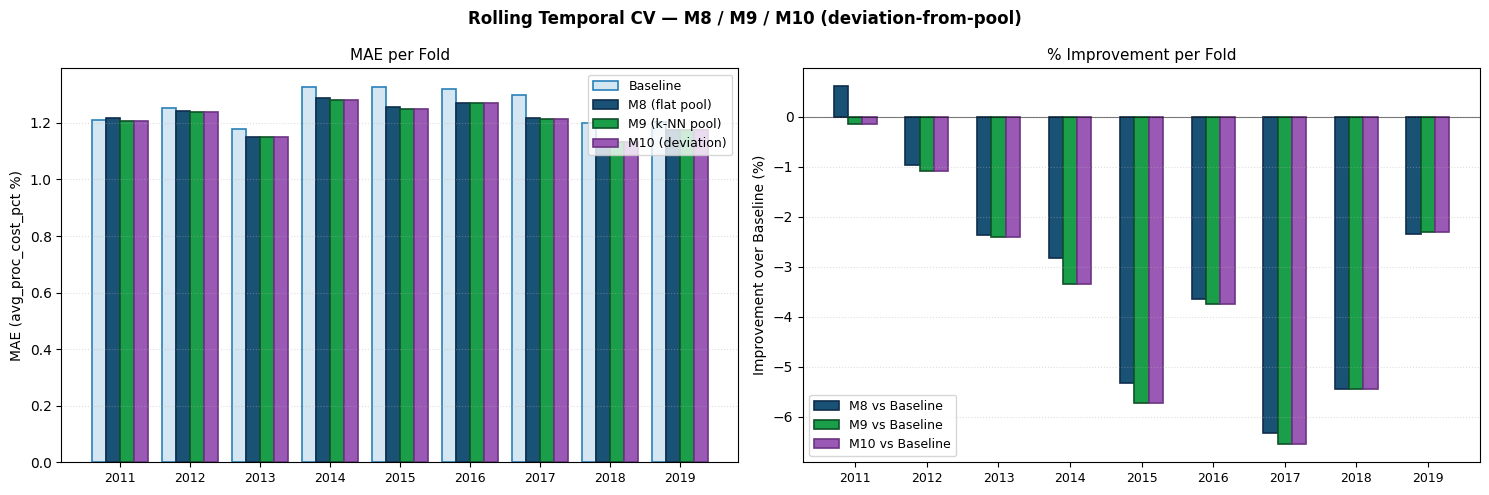

In [13]:
# Rolling CV visualisation — per-fold grouped bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Rolling Temporal CV — M8 / M9 / M10 (deviation-from-pool)', fontsize=12, fontweight='bold')

fold_labels = [str(r['cut_year']) for r in fold_results]
x           = np.arange(len(fold_labels))
bar_w       = 0.2

base_vals = [r['baseline_mae'] for r in fold_results]
m8_vals   = [r['m8_mae']       for r in fold_results]
m9_vals   = [r['m9_mae']       for r in fold_results]
m10_vals  = [r['m10_mae']      for r in fold_results]

ax1.bar(x - 1.5*bar_w, base_vals, bar_w, label='Baseline',
        color='#d4e6f1', edgecolor='#2980b9', linewidth=1.2)
ax1.bar(x - 0.5*bar_w, m8_vals,   bar_w, label='M8 (flat pool)',
        color='#1a5276', edgecolor='#0e2d4e', linewidth=1.2)
ax1.bar(x + 0.5*bar_w, m9_vals,   bar_w, label='M9 (k-NN pool)',
        color='#1a9e4a', edgecolor='#0e5228', linewidth=1.2)
ax1.bar(x + 1.5*bar_w, m10_vals,  bar_w, label='M10 (deviation)',
        color='#9b59b6', edgecolor='#6c3483', linewidth=1.2)
ax1.set_xticks(x)
ax1.set_xticklabels(fold_labels, fontsize=9)
ax1.set_ylabel('MAE (avg_proc_cost_pct %)', fontsize=10)
ax1.set_title('MAE per Fold', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle=':', alpha=0.4)

m8_impr_vals  = [r['m8_impr']  for r in fold_results]
m9_impr_vals  = [r['m9_impr']  for r in fold_results]
m10_impr_vals = [r['m10_impr'] for r in fold_results]

ax2.bar(x - bar_w,     m8_impr_vals,  bar_w, label='M8 vs Baseline',
        color='#1a5276', edgecolor='#0e2d4e', linewidth=1.2)
ax2.bar(x,             m9_impr_vals,  bar_w, label='M9 vs Baseline',
        color='#1a9e4a', edgecolor='#0e5228', linewidth=1.2)
ax2.bar(x + bar_w,     m10_impr_vals, bar_w, label='M10 vs Baseline',
        color='#9b59b6', edgecolor='#6c3483', linewidth=1.2)
ax2.axhline(0, color='black', linewidth=0.8, alpha=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(fold_labels, fontsize=9)
ax2.set_ylabel('Improvement over Baseline (%)', fontsize=10)
ax2.set_title('% Improvement per Fold', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()


## 8. Final Models + Pool-Based Conformal Prediction Intervals

Temporal filter selects the appropriate year window from each merchant group:

| Set | Merchant group | Temporal filter | Role |
|---|---|---|---|
| `train_ci` | train (60%) | horizon < `_cal_year` | Fit M8, M9, M10 final models |
| `cal_ci` | **validate (20%)** | horizon == `_cal_year` | Calibration residuals — unseen merchants |
| `test_ci` | **test (20%)** | horizon == `_test_year` | Fully held-out evaluation |

**M8** (`models_ci` / `scaler_ci`), **M9** (`models_knn` / `scaler_knn`), and **M10** (`models_dev` / `scaler_dev`) are all fit on the same train/cal/test partition with the same Huber parameters.  M10 trains on `y − pool_mean` (deviation) and reconstructs absolute predictions at inference by adding back the current k-NN pool mean. Pool-based conformal is computed separately for each model so interval widths can be fairly compared.


In [14]:
# Cal/test years derived dynamically
_ci_years  = sorted({int(s['horizon_data'].iloc[0]['year']) for s in valid_test_scenarios_1})
_cal_year  = _ci_years[-2]
_test_year = _ci_years[-1]

print(f"cal_year={_cal_year}  test_year={_test_year}")

# ── Temporal filter on merchant groups ────────────────────────────────────────
# Use horizon start (iloc[0]) as the cut boundary so that scenarios whose
# horizon begins before _cal_year are retained even if the last step spills in.
train_ci = [s for s in train_scenarios
            if int(s['horizon_data'].iloc[0]['year']) < _cal_year]
cal_ci   = [s for s in validate_scenarios
            if int(s['horizon_data'].iloc[0]['year']) == _cal_year]
test_ci  = [s for s in test_scenarios
            if int(s['horizon_data'].iloc[0]['year']) == _test_year]

print(f"train_ci={len(train_ci):,}  cal_ci={len(cal_ci):,}  test_ci={len(test_ci):,}")

# Common targets
y_tr  = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in train_ci])
y_cal = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in cal_ci])
y_te  = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in test_ci])

# ── M8: flat pool mean ─────────────────────────────────────────────────────────
X_tr_raw  = build_features_m8(train_ci, pool_mean_cache)
X_cal_raw = build_features_m8(cal_ci,   pool_mean_cache)
X_te_raw  = build_features_m8(test_ci,  pool_mean_cache)
sw        = 1.0 / (X_tr_raw[:, 3] + 1.0)

scaler_ci = StandardScaler()
X_tr  = scaler_ci.fit_transform(X_tr_raw)
X_cal = scaler_ci.transform(X_cal_raw)
X_te  = scaler_ci.transform(X_te_raw)

cal_preds = np.zeros_like(y_cal, dtype=float)
te_preds  = np.zeros_like(y_te,  dtype=float)
models_ci = []

for h in range(HORIZON_LEN):
    m = HuberRegressor(epsilon=1.35, max_iter=500)
    m.fit(X_tr, y_tr[:, h], sample_weight=sw)
    cal_preds[:, h] = m.predict(X_cal)
    te_preds[:, h]  = m.predict(X_te)
    models_ci.append(m)

cal_max_res_raw = np.abs(y_cal - cal_preds).max(axis=1)
q90_global      = float(np.quantile(cal_max_res_raw, 0.90))
print(f"\nM8: q90_global=±{q90_global:.4f}  "
      f"range=[{cal_max_res_raw.min():.4f}, {cal_max_res_raw.max():.4f}]")

# ── M9: k-NN pool mean ─────────────────────────────────────────────────────────
X_tr_knn_raw  = build_features_m8(train_ci, knn_pool_mean_cache)
X_cal_knn_raw = build_features_m8(cal_ci,   knn_pool_mean_cache)
X_te_knn_raw  = build_features_m8(test_ci,  knn_pool_mean_cache)
sw_knn        = 1.0 / (X_tr_knn_raw[:, 3] + 1.0)

scaler_knn = StandardScaler()
X_tr_knn  = scaler_knn.fit_transform(X_tr_knn_raw)
X_cal_knn = scaler_knn.transform(X_cal_knn_raw)
X_te_knn  = scaler_knn.transform(X_te_knn_raw)

cal_preds_knn = np.zeros_like(y_cal, dtype=float)
te_preds_knn  = np.zeros_like(y_te,  dtype=float)
models_knn    = []

for h in range(HORIZON_LEN):
    m = HuberRegressor(epsilon=1.35, max_iter=500)
    m.fit(X_tr_knn, y_tr[:, h], sample_weight=sw_knn)
    cal_preds_knn[:, h] = m.predict(X_cal_knn)
    te_preds_knn[:, h]  = m.predict(X_te_knn)
    models_knn.append(m)

cal_max_res_knn = np.abs(y_cal - cal_preds_knn).max(axis=1)
q90_global_knn  = float(np.quantile(cal_max_res_knn, 0.90))
print(f"M9: q90_global_knn=±{q90_global_knn:.4f}  "
      f"range=[{cal_max_res_knn.min():.4f}, {cal_max_res_knn.max():.4f}]")

# ── M10: k-NN pool mean, deviation target ─────────────────────────────────────
X_tr_dev_raw  = build_features_m8(train_ci, knn_pool_mean_cache)
X_cal_dev_raw = build_features_m8(cal_ci,   knn_pool_mean_cache)
X_te_dev_raw  = build_features_m8(test_ci,  knn_pool_mean_cache)
sw_dev        = 1.0 / (X_tr_dev_raw[:, 3] + 1.0)

pool_tr_dev   = X_tr_dev_raw[:, 3]
pool_cal_dev  = X_cal_dev_raw[:, 3]
pool_te_dev   = X_te_dev_raw[:, 3]

# Deviation targets
y_tr_dev_m10  = y_tr  - pool_tr_dev[:, None]
y_cal_dev_m10 = y_cal - pool_cal_dev[:, None]

scaler_dev = StandardScaler()
X_tr_dev  = scaler_dev.fit_transform(X_tr_dev_raw)
X_cal_dev = scaler_dev.transform(X_cal_dev_raw)
X_te_dev  = scaler_dev.transform(X_te_dev_raw)

cal_dev_preds = np.zeros_like(y_cal, dtype=float)
te_dev_preds  = np.zeros_like(y_te,  dtype=float)
models_dev    = []

for h in range(HORIZON_LEN):
    m = HuberRegressor(epsilon=1.35, max_iter=500)
    m.fit(X_tr_dev, y_tr_dev_m10[:, h], sample_weight=sw_dev)
    cal_dev_preds[:, h] = m.predict(X_cal_dev)
    te_dev_preds[:, h]  = m.predict(X_te_dev)
    models_dev.append(m)

# Reconstruct absolute predictions
cal_preds_dev = cal_dev_preds + pool_cal_dev[:, None]
te_preds_dev  = te_dev_preds  + pool_te_dev[:, None]

cal_max_res_dev = np.abs(y_cal - cal_preds_dev).max(axis=1)
q90_global_dev  = float(np.quantile(cal_max_res_dev, 0.90))
print(f"M10: q90_global_dev=±{q90_global_dev:.4f}  "
      f"range=[{cal_max_res_dev.min():.4f}, {cal_max_res_dev.max():.4f}]")


cal_year=2018  test_year=2019
train_ci=38,296  cal_ci=1,771  test_ci=1,132

M8: q90_global=±4.7275  range=[0.0483, 221.1186]
M9: q90_global_knn=±4.7357  range=[0.0446, 220.9185]
M10: q90_global_dev=±4.7357  range=[0.0446, 220.9183]


In [15]:
TARGET_COV = 0.90
MIN_POOL   = 10


def adaptive_q(residuals, target=TARGET_COV):
    """Finite-sample conformal quantile at level ceil((n+1)*target)/n."""
    n     = len(residuals)
    level = math.ceil((n + 1) * target) / n
    return float(np.quantile(residuals, level)) if level <= 1.0 else None


# ── M8 conformal ──────────────────────────────────────────────────────────────
cal_merchant_ids = np.array([s['merchant_id'] for s in cal_ci])
merchant_cal_res = defaultdict(list)
for i, res in enumerate(cal_max_res_raw):
    merchant_cal_res[int(cal_merchant_ids[i])].append(float(res))

print(f"Cal merchants: {len(merchant_cal_res)}  "
      f"total residuals: {sum(len(v) for v in merchant_cal_res.values())}")

hw_per_scenario = np.zeros(len(test_ci))
pool_cal_sizes  = []
pool_stats      = {'local': 0, 'global_fallback': 0}

for i, s in enumerate(test_ci):
    yr, mo    = s['context_range'][1]
    peer_mids = set(int(p) for p in
                    generate_pool(df_5411_sample, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
    peer_res  = [r for peer in peer_mids for r in merchant_cal_res.get(peer, [])]
    pool_cal_sizes.append(len(peer_res))

    q_local = adaptive_q(peer_res) if len(peer_res) >= MIN_POOL else None
    if q_local is not None:
        hw_per_scenario[i] = q_local
        pool_stats['local'] += 1
    else:
        hw_per_scenario[i] = q90_global
        pool_stats['global_fallback'] += 1

lo_pool = np.clip(te_preds - hw_per_scenario[:, None], 0, None)
hi_pool = te_preds + hw_per_scenario[:, None]

in_pool    = (y_te >= lo_pool) & (y_te <= hi_pool)
joint_pool = float(np.mean(in_pool.all(axis=1)))
marg_pool  = float(np.mean(in_pool))
width_pool = float(np.mean(hi_pool - lo_pool))

print(f"\nM8 conformal @ {TARGET_COV*100:.0f}%  "
      f"local={pool_stats['local']} ({pool_stats['local']/len(test_ci)*100:.0f}%)  "
      f"fallback={pool_stats['global_fallback']}")
print(f"  joint={joint_pool:.3f}  marginal={marg_pool:.3f}  "
      f"avg half-width=±{width_pool/2:.4f}  (global ±{q90_global:.4f})")

# ── M9 conformal ──────────────────────────────────────────────────────────────
merchant_cal_res_knn = defaultdict(list)
for i, res in enumerate(cal_max_res_knn):
    merchant_cal_res_knn[int(cal_merchant_ids[i])].append(float(res))

hw_per_scenario_knn = np.zeros(len(test_ci))
pool_stats_knn      = {'local': 0, 'global_fallback': 0}

for i, s in enumerate(test_ci):
    yr, mo    = s['context_range'][1]
    peer_mids = set(int(p) for p in
                    generate_pool(df_5411_sample, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
    peer_res  = [r for peer in peer_mids for r in merchant_cal_res_knn.get(peer, [])]

    q_local = adaptive_q(peer_res) if len(peer_res) >= MIN_POOL else None
    if q_local is not None:
        hw_per_scenario_knn[i] = q_local
        pool_stats_knn['local'] += 1
    else:
        hw_per_scenario_knn[i] = q90_global_knn
        pool_stats_knn['global_fallback'] += 1

lo_pool_knn = np.clip(te_preds_knn - hw_per_scenario_knn[:, None], 0, None)
hi_pool_knn = te_preds_knn + hw_per_scenario_knn[:, None]

in_pool_knn    = (y_te >= lo_pool_knn) & (y_te <= hi_pool_knn)
joint_pool_knn = float(np.mean(in_pool_knn.all(axis=1)))
marg_pool_knn  = float(np.mean(in_pool_knn))
width_pool_knn = float(np.mean(hi_pool_knn - lo_pool_knn))

print(f"\nM9 conformal @ {TARGET_COV*100:.0f}%  "
      f"local={pool_stats_knn['local']} ({pool_stats_knn['local']/len(test_ci)*100:.0f}%)  "
      f"fallback={pool_stats_knn['global_fallback']}")
print(f"  joint={joint_pool_knn:.3f}  marginal={marg_pool_knn:.3f}  "
      f"avg half-width=±{width_pool_knn/2:.4f}  (global ±{q90_global_knn:.4f})")

# ── M10 conformal ─────────────────────────────────────────────────────────────
merchant_cal_res_dev = defaultdict(list)
for i, res in enumerate(cal_max_res_dev):
    merchant_cal_res_dev[int(cal_merchant_ids[i])].append(float(res))

hw_per_scenario_dev = np.zeros(len(test_ci))
pool_stats_dev      = {'local': 0, 'global_fallback': 0}

for i, s in enumerate(test_ci):
    yr, mo    = s['context_range'][1]
    peer_mids = set(int(p) for p in
                    generate_pool(df_5411_sample, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
    peer_res  = [r for peer in peer_mids for r in merchant_cal_res_dev.get(peer, [])]

    q_local = adaptive_q(peer_res) if len(peer_res) >= MIN_POOL else None
    if q_local is not None:
        hw_per_scenario_dev[i] = q_local
        pool_stats_dev['local'] += 1
    else:
        hw_per_scenario_dev[i] = q90_global_dev
        pool_stats_dev['global_fallback'] += 1

lo_pool_dev = np.clip(te_preds_dev - hw_per_scenario_dev[:, None], 0, None)
hi_pool_dev = te_preds_dev + hw_per_scenario_dev[:, None]

in_pool_dev    = (y_te >= lo_pool_dev) & (y_te <= hi_pool_dev)
joint_pool_dev = float(np.mean(in_pool_dev.all(axis=1)))
marg_pool_dev  = float(np.mean(in_pool_dev))
width_pool_dev = float(np.mean(hi_pool_dev - lo_pool_dev))

print(f"\nM10 conformal @ {TARGET_COV*100:.0f}%  "
      f"local={pool_stats_dev['local']} ({pool_stats_dev['local']/len(test_ci)*100:.0f}%)  "
      f"fallback={pool_stats_dev['global_fallback']}")
print(f"  joint={joint_pool_dev:.3f}  marginal={marg_pool_dev:.3f}  "
      f"avg half-width=±{width_pool_dev/2:.4f}  (global ±{q90_global_dev:.4f})")

# ── Side-by-side summary ───────────────────────────────────────────────────────
print(f"\n{'─'*64}")
print(f"{'Metric':<28}  {'M8 (flat)':>10}  {'M9 (k-NN)':>10}  {'M10 (dev)':>10}")
print(f"{'─'*64}")
print(f"{'Joint coverage':<28}  {joint_pool:>10.3f}  {joint_pool_knn:>10.3f}  {joint_pool_dev:>10.3f}")
print(f"{'Marginal coverage':<28}  {marg_pool:>10.3f}  {marg_pool_knn:>10.3f}  {marg_pool_dev:>10.3f}")
print(f"{'Avg half-width (pp)':<28}  {width_pool/2:>10.4f}  {width_pool_knn/2:>10.4f}  {width_pool_dev/2:>10.4f}")
print(f"{'─'*64}")


Cal merchants: 169  total residuals: 1771

M8 conformal @ 90%  local=1132 (100%)  fallback=0
  joint=0.906  marginal=0.954  avg half-width=±4.0225  (global ±4.7275)

M9 conformal @ 90%  local=1132 (100%)  fallback=0
  joint=0.906  marginal=0.954  avg half-width=±4.0183  (global ±4.7357)

M10 conformal @ 90%  local=1132 (100%)  fallback=0
  joint=0.906  marginal=0.954  avg half-width=±4.0183  (global ±4.7357)

────────────────────────────────────────────────────────────────
Metric                         M8 (flat)   M9 (k-NN)   M10 (dev)
────────────────────────────────────────────────────────────────
Joint coverage                     0.906       0.906       0.906
Marginal coverage                  0.954       0.954       0.954
Avg half-width (pp)               4.0225      4.0183      4.0183
────────────────────────────────────────────────────────────────


## 9. Residual-Aware Volatility-Stratified Conformal Intervals

The pool-local conformal interval already adapts to peer residuals, but it still treats all merchants with the same calibration mechanism. The goal here is to separate stable merchants from structurally noisy merchants so that stable merchants receive tighter intervals and the volatile tail absorbs the wider penalties.

**Updated approach:** a learned residual-risk score combines context stability and peer-pool composition, trained on **cross-fitted M9 residuals from the training folds**. The deployed interval is no longer a hard bucket-only width. Instead, the learned score drives a **continuous monotone width-adjustment curve**, with percentile schemes only used to place candidate knots on that curve.

| Component | Detail |
|---|---|
| **Richer context signal** | Context CoV, range / mean, slope / mean, and last-step jump / mean |
| **Peer-pool composition** | Flat-vs-kNN pool mean gap and context-vs-kNN pool gap |
| **Non-linear risk model** | Gradient boosting regressor on `log(1 + residual)` for each forecast horizon |
| **Cross-fitted targets** | Risk-model targets come from out-of-fold M9 residuals on `train_ci`, reducing optimism |
| **Continuous adjustment** | Knot schemes define a monotone piecewise-linear width curve over the learned risk score |
| **Leak control** | Scheme selection is still done on a merchant-disjoint calibration holdout, not on the final test set |
| **Practical-gain rule** | A scheme is only accepted if it meets target coverage and improves average half-width by a minimum meaningful amount |

In [20]:
# ── Section 9 setup: constants, feature names, scheme grid, risk_features ─────

_VOL_EPS         = 1e-6
VOL_MIN_GAIN_ABS = 0.05
VOL_MIN_GAIN_REL = 0.01

RISK_FEATURE_NAMES = [
    'ctx_cov',
    'ctx_range_ratio',
    'ctx_slope_ratio',
    'ctx_last_jump_ratio',
    'pool_mean_gap_ratio',
    'ctx_to_knn_gap_ratio',
]

# Candidate percentile schemes — knots define bin edges on the risk-score CDF.
# Naming convention: band labels underscore-separated knot percentiles.
VOL_BUCKET_SCHEMES = {
    'low-mid-high_50_85':          [0.00, 0.50, 0.85, 1.00],
    'low-mid-high_40_80':          [0.00, 0.40, 0.80, 1.00],
    'low-mid-high_60_90':          [0.00, 0.60, 0.90, 1.00],
    'low-mid-high-vhigh_50_75_90': [0.00, 0.50, 0.75, 0.90, 1.00],
    'low-mid-high-vhigh_40_70_88': [0.00, 0.40, 0.70, 0.88, 1.00],
    'low-mid-high-vhigh_60_85_95': [0.00, 0.60, 0.85, 0.95, 1.00],
}

VOL_LABELS_BY_COUNT = {
    1: ['Global'],
    2: ['Low', 'High'],
    3: ['Low', 'Mid', 'High'],
    4: ['Low', 'Mid', 'High', 'VHigh'],
}


def risk_features(s):
    """Compute 6 residual-risk features for a single scenario.

    Features
    --------
    ctx_cov              : CoV of context avg_proc_cost_pct values
    ctx_range_ratio      : (max - min) / mean — context spread
    ctx_slope_ratio      : OLS slope / mean — trend direction & magnitude
    ctx_last_jump_ratio  : last step change / mean — recency shock
    pool_mean_gap_ratio  : |ctx_mean - flat_pool_mean| / flat_pool_mean
    ctx_to_knn_gap_ratio : |ctx_mean - knn_pool_mean|  / knn_pool_mean
    """
    vals   = s['context_data']['avg_proc_cost_pct'].values.astype(float)
    c_mean = float(np.mean(vals))
    _denom = c_mean + _VOL_EPS          # safe denominator

    ctx_cov         = float(np.std(vals)) / _denom
    ctx_range_ratio = (float(np.max(vals)) - float(np.min(vals))) / _denom

    x_idx           = np.arange(len(vals), dtype=float)
    ctx_slope_ratio = float(np.polyfit(x_idx, vals, 1)[0]) / _denom

    ctx_last_jump_ratio = (
        (float(vals[-1]) - float(vals[-2])) / _denom if len(vals) >= 2 else 0.0
    )

    yr, mo  = s['context_range'][1]
    mid     = int(s['merchant_id'])
    flat_pm = float(pool_mean_cache.get((mid, yr, mo), c_mean))
    knn_pm  = float(knn_pool_mean_cache.get((mid, yr, mo), c_mean))

    pool_mean_gap_ratio  = abs(c_mean - flat_pm) / (flat_pm + _VOL_EPS)
    ctx_to_knn_gap_ratio = abs(c_mean - knn_pm)  / (knn_pm  + _VOL_EPS)

    return np.array([
        ctx_cov, ctx_range_ratio, ctx_slope_ratio, ctx_last_jump_ratio,
        pool_mean_gap_ratio, ctx_to_knn_gap_ratio,
    ], dtype=float)


print('Section 9 setup complete.')
print(f'  Risk features : {RISK_FEATURE_NAMES}')
print(f'  VOL schemes   : {list(VOL_BUCKET_SCHEMES.keys())}')


Section 9 setup complete.
  Risk features : ['ctx_cov', 'ctx_range_ratio', 'ctx_slope_ratio', 'ctx_last_jump_ratio', 'pool_mean_gap_ratio', 'ctx_to_knn_gap_ratio']
  VOL schemes   : ['low-mid-high_50_85', 'low-mid-high_40_80', 'low-mid-high_60_90', 'low-mid-high-vhigh_50_75_90', 'low-mid-high-vhigh_40_70_88', 'low-mid-high-vhigh_60_85_95']


In [21]:
# ── 1. Compute residual-risk features for train / calibration / test scenarios ─
from sklearn.ensemble import GradientBoostingRegressor

train_feat = np.vstack([risk_features(s) for s in train_ci]).astype(float)
cal_feat = np.vstack([risk_features(s) for s in cal_ci]).astype(float)
te_feat = np.vstack([risk_features(s) for s in test_ci]).astype(float)


def _effective_half_width(lo, hi):
    return (hi - lo) / 2.0


def _fit_risk_model(x, residual_target):
    """Fit a shallow boosted tree on log residual scale."""
    model = GradientBoostingRegressor(
        loss='squared_error',
        n_estimators=120,
        learning_rate=0.05,
        max_depth=2,
        min_samples_leaf=max(20, MIN_POOL),
        subsample=0.8,
        random_state=4121,
    )
    model.fit(x, np.log1p(residual_target.astype(float)))
    return model


def _apply_risk_model(model, x):
    return model.predict(x)


# ── 2. Cross-fitted horizon-specific residual targets from train folds ─────────
train_years = np.array([int(s['horizon_data'].iloc[0]['year']) for s in train_ci])
train_cf_res = np.full((len(train_ci), HORIZON_LEN), np.nan, dtype=float)

for cut in fold_cuts:
    cf_train_mask = train_years < cut
    cf_test_mask = train_years == cut
    if cf_train_mask.sum() == 0 or cf_test_mask.sum() == 0:
        continue

    cf_train = [train_ci[i] for i in np.where(cf_train_mask)[0]]
    cf_test = [train_ci[i] for i in np.where(cf_test_mask)[0]]
    y_cf_train = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in cf_train])
    y_cf_test = np.array([s['horizon_data']['avg_proc_cost_pct'].values for s in cf_test])

    X_cf_train_raw = build_features_m8(cf_train, knn_pool_mean_cache)
    X_cf_test_raw = build_features_m8(cf_test, knn_pool_mean_cache)
    sw_cf = 1.0 / (X_cf_train_raw[:, 3] + 1.0)

    scaler_cf = StandardScaler()
    X_cf_train = scaler_cf.fit_transform(X_cf_train_raw)
    X_cf_test = scaler_cf.transform(X_cf_test_raw)

    preds_cf = np.zeros_like(y_cf_test, dtype=float)
    for h in range(HORIZON_LEN):
        model_cf = HuberRegressor(epsilon=1.35, max_iter=500)
        model_cf.fit(X_cf_train, y_cf_train[:, h], sample_weight=sw_cf)
        preds_cf[:, h] = model_cf.predict(X_cf_test)

    train_cf_res[cf_test_mask] = np.abs(y_cf_test - preds_cf)

cf_valid_mask = np.isfinite(train_cf_res).all(axis=1)
if cf_valid_mask.sum() < MIN_POOL:
    raise ValueError('Cross-fitted residual dataset is too small for risk-model training.')

risk_models = [
    _fit_risk_model(train_feat[cf_valid_mask], train_cf_res[cf_valid_mask, h])
    for h in range(HORIZON_LEN)
]
cal_risk_h = np.column_stack([_apply_risk_model(model, cal_feat) for model in risk_models])
te_risk_h = np.column_stack([_apply_risk_model(model, te_feat) for model in risk_models])
cal_risk_score = np.max(cal_risk_h, axis=1)
te_risk_score = np.max(te_risk_h, axis=1)

print(f'Cross-fitted train residuals available: {cf_valid_mask.sum():,} / {len(train_ci):,}')
print('Residual-risk feature importances (average over horizons):')
for fname, imp in zip(
    RISK_FEATURE_NAMES,
    np.mean(np.vstack([model.feature_importances_ for model in risk_models]), axis=0),
):
    print(f'  {fname:<20} {imp:.4f}')


# ── 3. Leak-free scheme selection on a calibration holdout ────────────────────
_VOL_SELECT_SEED = 4121
_VOL_SELECT_FRAC = 0.70

_cal_mids = np.array(sorted(set(cal_merchant_ids.tolist())))
if len(_cal_mids) < 2:
    raise ValueError('Need at least two calibration merchants for residual-aware volatility selection.')

_rng = np.random.default_rng(_VOL_SELECT_SEED)
_perm = _rng.permutation(_cal_mids)
_cut = min(max(1, int(round(len(_perm) * _VOL_SELECT_FRAC))), len(_perm) - 1)
_sel_mids = set(_perm[:_cut].tolist())

sel_mask = np.isin(cal_merchant_ids, list(_sel_mids))
eval_mask = ~sel_mask
if sel_mask.sum() < MIN_POOL or eval_mask.sum() < MIN_POOL:
    raise ValueError('Calibration split is too small for residual-aware volatility selection.')

y_eval = y_cal[eval_mask]
preds_eval_knn = cal_preds_knn[eval_mask]
eval_ci = [cal_ci[i] for i in np.where(eval_mask)[0]]

merchant_sel_res_knn = defaultdict(list)
for mid, res in zip(cal_merchant_ids[sel_mask], cal_max_res_knn[sel_mask]):
    merchant_sel_res_knn[int(mid)].append(float(res))

global_q_sel_knn = adaptive_q(cal_max_res_knn[sel_mask].tolist())
if global_q_sel_knn is None:
    global_q_sel_knn = q90_global_knn

hw_eval_pool = np.zeros(eval_mask.sum(), dtype=float)
for i, s in enumerate(eval_ci):
    yr, mo = s['context_range'][1]
    peer_mids = set(
        int(p) for p in generate_pool(df_5411_sample, int(s['merchant_id']), yr, mo)['merchant_id'].unique()
    )
    peer_res = [r for peer in peer_mids for r in merchant_sel_res_knn.get(peer, [])]
    q_local = adaptive_q(peer_res) if len(peer_res) >= MIN_POOL else None
    hw_eval_pool[i] = q_local if q_local is not None else global_q_sel_knn

lo_eval_pool = np.clip(preds_eval_knn - hw_eval_pool[:, None], 0, None)
hi_eval_pool = preds_eval_knn + hw_eval_pool[:, None]
in_eval_pool = (y_eval >= lo_eval_pool) & (y_eval <= hi_eval_pool)

baseline_eval = {
    'avg_hw': float(np.mean(_effective_half_width(lo_eval_pool, hi_eval_pool))),
    'joint_cov': float(np.mean(in_eval_pool.all(axis=1))),
    'n_eval': int(eval_mask.sum()),
}
_min_gain_holdout = max(VOL_MIN_GAIN_ABS, VOL_MIN_GAIN_REL * baseline_eval['avg_hw'])

sel_risk_score = cal_risk_score[sel_mask]
eval_risk_score = cal_risk_score[eval_mask]


def _make_percentile_bins(ref_vals, apply_vals, pct_edges, min_count=MIN_POOL):
    """Build knot bins from a reference score and apply them elsewhere."""
    pct_edges = np.array(pct_edges, dtype=float)
    edges = np.quantile(ref_vals, pct_edges)
    edges = np.maximum.accumulate(edges)
    edges = np.unique(edges)

    n_eff = len(edges) - 1
    if n_eff < 2:
        return None

    ref_bins = np.digitize(ref_vals, edges[1:-1], right=False)
    counts = np.array([(ref_bins == b).sum() for b in range(n_eff)])
    if counts.min() < min_count:
        return None

    apply_bins = np.digitize(apply_vals, edges[1:-1], right=False)
    return edges, ref_bins, apply_bins, n_eff, counts


def _continuous_width_map(cal_scores_ref, apply_scores, cal_res, pct_edges, q_fallback):
    built = _make_percentile_bins(cal_scores_ref, apply_scores, pct_edges, min_count=MIN_POOL)
    if built is None:
        return None

    edges, ref_bins, apply_bins, n_eff, counts = built
    q_vals = []
    for b in range(n_eff):
        res_b = cal_res[ref_bins == b].tolist()
        q_local = adaptive_q(res_b) if len(res_b) >= MIN_POOL else None
        q_vals.append(q_local if q_local is not None else q_fallback)
    q_vals = np.maximum.accumulate(np.array(q_vals, dtype=float))
    knot_x = 0.5 * (edges[:-1] + edges[1:])
    knot_x = np.maximum.accumulate(knot_x + np.arange(len(knot_x)) * 1e-9)
    hw_apply = np.interp(apply_scores, knot_x, q_vals, left=q_vals[0], right=q_vals[-1])
    return {
        'edges': edges,
        'ref_bins': ref_bins,
        'apply_bins': apply_bins,
        'active': n_eff,
        'counts': counts,
        'knot_x': knot_x,
        'q_vals': q_vals,
        'hw_apply': hw_apply,
    }


def _eval_scheme(name, pct_edges):
    mapped = _continuous_width_map(sel_risk_score, eval_risk_score, cal_max_res_knn[sel_mask], pct_edges, global_q_sel_knn)
    if mapped is None:
        return None

    hw = mapped['hw_apply']
    lo = np.clip(preds_eval_knn - hw[:, None], 0, None)
    hi = preds_eval_knn + hw[:, None]
    in_ = (y_eval >= lo) & (y_eval <= hi)
    avg_hw = float(np.mean(_effective_half_width(lo, hi)))
    joint_cov = float(np.mean(in_.all(axis=1)))

    return {
        'name': name,
        'pct_edges': np.array(pct_edges, dtype=float),
        'active': mapped['active'],
        'counts': mapped['counts'],
        'avg_hw': avg_hw,
        'joint_cov': joint_cov,
        'gain_vs_baseline': baseline_eval['avg_hw'] - avg_hw,
        'q_knn': mapped['q_vals'],
        'knot_x': mapped['knot_x'],
        'edges_holdout': mapped['edges'],
        'n_eval_by_bin': [int((mapped['apply_bins'] == b).sum()) for b in range(mapped['active'])],
    }


# ── 4. Auto-select residual-aware continuous-width scheme ─────────────────────
print(f"{'─'*132}")
print('Residual-aware continuous-width auto-selection on calibration holdout')
print(f"Selection split: q-fit scenarios={sel_mask.sum()}  holdout scenarios={eval_mask.sum()}")
print(
    f"Pool-local baseline on holdout: avg_hw={baseline_eval['avg_hw']:.4f}  "
    f"joint_cov={baseline_eval['joint_cov']:.3f}  min_gain={_min_gain_holdout:.4f}"
)
print(f"{'Scheme':<34}  {'Knots':>5}  {'avg_hw':>9}  {'joint_cov':>10}  {'gain':>9}  {'status':>12}  {'holdout_band_counts':>24}")
print(f"{'─'*132}")

_scheme_results = []
for _name, _pct in VOL_BUCKET_SCHEMES.items():
    _res = _eval_scheme(_name, _pct)
    if _res is None:
        print(f"{_name:<34}  {'-':>5}  {'-':>9}  {'-':>10}  {'-':>9}  {'invalid':>12}  {'-':>24}")
        continue
    _beats = (_res['joint_cov'] >= TARGET_COV) and (_res['gain_vs_baseline'] >= _min_gain_holdout)
    _status = 'ACCEPT' if _beats else 'keep global'
    print(
        f"{_name:<34}  {_res['active']:>5}  {_res['avg_hw']:>9.4f}  {_res['joint_cov']:>10.3f}  "
        f"{_res['gain_vs_baseline']:>+9.4f}  {_status:>12}  {str(_res['n_eval_by_bin']):>24}"
    )
    _scheme_results.append(_res)

_feasible = [
    r for r in _scheme_results
    if (r['joint_cov'] >= TARGET_COV) and (r['gain_vs_baseline'] >= _min_gain_holdout)
]
_USE_STRATIFIED_VOL = bool(_feasible)

if _USE_STRATIFIED_VOL:
    _best = min(_feasible, key=lambda r: (r['avg_hw'], r['active']))
else:
    _best = None

print(f"{'─'*132}")
if _USE_STRATIFIED_VOL:
    print(
        f"Chosen scheme: { _best['name'] }  |  knots={_best['active']}  |  "
        f"holdout avg_hw={_best['avg_hw']:.4f}  |  holdout joint_cov={_best['joint_cov']:.3f}  "
        f"|  gain={_best['gain_vs_baseline']:+.4f}"
    )
else:
    print('No residual-aware continuous-width scheme beat the pool-local baseline by the minimum practical gain on the calibration holdout.')
    print('Falling back to the existing pool-local conformal intervals for deployment.')
print(f"{'─'*132}")

if _USE_STRATIFIED_VOL:
    _display = _make_percentile_bins(cal_risk_score, te_risk_score, _best['pct_edges'], min_count=MIN_POOL)
    if _display is None:
        _USE_STRATIFIED_VOL = False

if _USE_STRATIFIED_VOL:
    VOL_SCHEME_NAME = _best['name']
    VOL_EDGES, cal_vol_bins, te_vol_bins, N_VOL_BINS_ACTIVE, _ = _display
else:
    VOL_SCHEME_NAME = 'global_fallback'
    VOL_EDGES = np.array([float(np.min(cal_risk_score)), float(np.max(cal_risk_score) + _VOL_EPS)], dtype=float)
    cal_vol_bins = np.zeros(len(cal_risk_score), dtype=int)
    te_vol_bins = np.zeros(len(te_risk_score), dtype=int)
    N_VOL_BINS_ACTIVE = 1

VOL_LABELS_ACTIVE = VOL_LABELS_BY_COUNT.get(
    N_VOL_BINS_ACTIVE, [f'B{b+1}' for b in range(N_VOL_BINS_ACTIVE)]
)

for b, lbl in enumerate(VOL_LABELS_ACTIVE):
    lo = VOL_EDGES[b]
    hi = VOL_EDGES[b + 1]
    n_cal = int((cal_vol_bins == b).sum())
    n_te = int((te_vol_bins == b).sum())
    print(f"  {lbl:<9} [{lo:.4f}, {hi:.4f}]  cal={n_cal:4d}  test={n_te:4d}")


# ── 5. Build continuous deployed intervals from risk score ────────────────────
q_strat = {}
if _USE_STRATIFIED_VOL:
    width_maps = {}
    for mlabel, cal_res, q_fallback in [
        ('M8', cal_max_res_raw, q90_global),
        ('M9', cal_max_res_knn, q90_global_knn),
        ('M10', cal_max_res_dev, q90_global_dev),
    ]:
        mapped = _continuous_width_map(cal_risk_score, te_risk_score, cal_res, _best['pct_edges'], q_fallback)
        width_maps[mlabel] = mapped
        q_strat[mlabel] = {b: float(mapped['q_vals'][b]) for b in range(mapped['active'])}
        print(f"\n{mlabel} — continuous width knots:")
        for b, lbl in enumerate(VOL_LABELS_ACTIVE):
            print(
                f"  {lbl:<9}: n_cal={mapped['counts'][b]:4d}  q=±{mapped['q_vals'][b]:.4f}  "
                f"(global=±{q_fallback:.4f}  Δ={mapped['q_vals'][b] - q_fallback:+.4f})"
            )

    hw_strat_m8 = width_maps['M8']['hw_apply']
    hw_strat_m9 = width_maps['M9']['hw_apply']
    hw_strat_m10 = width_maps['M10']['hw_apply']
else:
    print('\nUsing existing pool-local conformal intervals; residual-aware stratification disabled.')
    q_strat = {
        'M8': {0: float(np.mean(_effective_half_width(lo_pool, hi_pool)))},
        'M9': {0: float(np.mean(_effective_half_width(lo_pool_knn, hi_pool_knn)))},
        'M10': {0: float(np.mean(_effective_half_width(lo_pool_dev, hi_pool_dev)))},
    }
    hw_strat_m8 = hw_per_scenario.copy()
    hw_strat_m9 = hw_per_scenario_knn.copy()
    hw_strat_m10 = hw_per_scenario_dev.copy()

lo_strat_m8 = np.clip(te_preds - hw_strat_m8[:, None], 0, None)
hi_strat_m8 = te_preds + hw_strat_m8[:, None]
lo_strat_m9 = np.clip(te_preds_knn - hw_strat_m9[:, None], 0, None)
hi_strat_m9 = te_preds_knn + hw_strat_m9[:, None]
lo_strat_m10 = np.clip(te_preds_dev - hw_strat_m10[:, None], 0, None)
hi_strat_m10 = te_preds_dev + hw_strat_m10[:, None]


# ── 6. Overall coverage and width summary ──────────────────────────────────────
strat_results = {}
print(f"\n{'─'*84}")
print(f"{'Model':<6}  {'Joint Global':>13}  {'Joint Strat':>12}  {'hw Global':>10}  {'hw Strat':>10}  {'Δhw':>8}")
print(f"{'─'*84}")

for mlabel, lo_g, hi_g, lo_s, hi_s in [
    ('M8', lo_pool, hi_pool, lo_strat_m8, hi_strat_m8),
    ('M9', lo_pool_knn, hi_pool_knn, lo_strat_m9, hi_strat_m9),
    ('M10', lo_pool_dev, hi_pool_dev, lo_strat_m10, hi_strat_m10),
]:
    in_g = (y_te >= lo_g) & (y_te <= hi_g)
    in_s = (y_te >= lo_s) & (y_te <= hi_s)

    joint_g = float(np.mean(in_g.all(axis=1)))
    joint_s = float(np.mean(in_s.all(axis=1)))
    avg_hw_g = float(np.mean(_effective_half_width(lo_g, hi_g)))
    avg_hw_s = float(np.mean(_effective_half_width(lo_s, hi_s)))
    delta_hw = avg_hw_s - avg_hw_g

    strat_results[mlabel] = dict(
        joint_g=joint_g,
        joint_s=joint_s,
        hw_g=avg_hw_g,
        hw_s=avg_hw_s,
        delta_hw=delta_hw,
    )
    direction = '▼ narrower' if delta_hw < 0 else '▲ wider' if delta_hw > 0 else '= same'
    print(f"{mlabel:<6}  {joint_g:>13.3f}  {joint_s:>12.3f}  {avg_hw_g:>10.4f}  {avg_hw_s:>10.4f}  {delta_hw:>+8.4f}  {direction}")

print(f"{'─'*84}")


# ── 7. Per-band coverage breakdown (display bands only) ───────────────────────
print(f"\nPer-band coverage on test set (target = {TARGET_COV:.0%}):")
for mlabel, lo_s, hi_s in [
    ('M8', lo_strat_m8, hi_strat_m8),
    ('M9', lo_strat_m9, hi_strat_m9),
    ('M10', lo_strat_m10, hi_strat_m10),
]:
    print(f"\n  {mlabel}:")
    for b, lbl in enumerate(VOL_LABELS_ACTIVE):
        mask_b = te_vol_bins == b
        if mask_b.sum() == 0:
            continue
        in_b = (y_te[mask_b] >= lo_s[mask_b]) & (y_te[mask_b] <= hi_s[mask_b])
        jt = float(np.mean(in_b.all(axis=1)))
        mg = float(np.mean(in_b))
        eff_hw = float(np.mean(_effective_half_width(lo_s[mask_b], hi_s[mask_b])))
        flag = '✓' if jt >= TARGET_COV else '✗'
        print(f"    {flag} {lbl:<9}: n={mask_b.sum():4d}  joint={jt:.3f}  marginal={mg:.3f}  avg hw=±{eff_hw:.4f}")

Cross-fitted train residuals available: 35,943 / 38,296
Residual-risk feature importances (average over horizons):
  ctx_cov              0.1482
  ctx_range_ratio      0.0199
  ctx_slope_ratio      0.0008
  ctx_last_jump_ratio  0.0044
  pool_mean_gap_ratio  0.6990
  ctx_to_knn_gap_ratio 0.1278
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Residual-aware continuous-width auto-selection on calibration holdout
Selection split: q-fit scenarios=1260  holdout scenarios=511
Pool-local baseline on holdout: avg_hw=4.3045  joint_cov=0.939  min_gain=0.0500
Scheme                              Knots     avg_hw   joint_cov       gain        status       holdout_band_counts
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
low-mid-high_50_85                      3     3.3097       0.924    +0.9948        ACCEPT            [272, 196, 

In [22]:
# ── 8. Analysis-time deployment guard ──────────────────────────────────────────
# Section 11 is exploratory. Keep a guard, but allow near-target deployments when
# the test undercoverage is small and the width improvement is still material.
VOL_TEST_COV_SLACK = 0.03

_candidate_joint_m9 = float(np.mean(((y_te >= lo_strat_m9) & (y_te <= hi_strat_m9)).all(axis=1)))
_candidate_avg_hw_m9 = float(np.mean(_effective_half_width(lo_strat_m9, hi_strat_m9)))
_global_avg_hw_m9 = float(np.mean(_effective_half_width(lo_pool_knn, hi_pool_knn)))
_min_gain_test = max(VOL_MIN_GAIN_ABS, VOL_MIN_GAIN_REL * _global_avg_hw_m9)
_coverage_floor_test = TARGET_COV - VOL_TEST_COV_SLACK

if (VOL_SCHEME_NAME != 'global_fallback') and not (
    (_candidate_joint_m9 >= _coverage_floor_test) and ((_global_avg_hw_m9 - _candidate_avg_hw_m9) >= _min_gain_test)
):
    print('\nAnalysis-time guard: selected volatility scheme is too far below the allowed test coverage floor or does not beat the deployed M9 pool-local baseline by a practical margin.')
    print(f'Coverage floor used: {_coverage_floor_test:.3f} (target={TARGET_COV:.3f}, slack={VOL_TEST_COV_SLACK:.3f})')
    print('Reverting notebook state to the existing pool-local conformal intervals.')

    VOL_SCHEME_NAME = 'global_fallback'
    VOL_EDGES = np.array([float(np.min(cal_risk_score)), float(np.max(cal_risk_score) + _VOL_EPS)], dtype=float)
    cal_vol_bins = np.zeros(len(cal_risk_score), dtype=int)
    te_vol_bins = np.zeros(len(te_risk_score), dtype=int)
    N_VOL_BINS_ACTIVE = 1
    VOL_LABELS_ACTIVE = VOL_LABELS_BY_COUNT[1]

    q_strat = {
        'M8': {0: float(np.mean(_effective_half_width(lo_pool, hi_pool)))},
        'M9': {0: float(np.mean(_effective_half_width(lo_pool_knn, hi_pool_knn)))},
        'M10': {0: float(np.mean(_effective_half_width(lo_pool_dev, hi_pool_dev)))},
    }

    hw_strat_m8 = hw_per_scenario.copy()
    hw_strat_m9 = hw_per_scenario_knn.copy()
    hw_strat_m10 = hw_per_scenario_dev.copy()

    lo_strat_m8 = lo_pool.copy()
    hi_strat_m8 = hi_pool.copy()
    lo_strat_m9 = lo_pool_knn.copy()
    hi_strat_m9 = hi_pool_knn.copy()
    lo_strat_m10 = lo_pool_dev.copy()
    hi_strat_m10 = hi_pool_dev.copy()

    strat_results = {}
    for mlabel, lo_g, hi_g, lo_s, hi_s in [
        ('M8', lo_pool, hi_pool, lo_strat_m8, hi_strat_m8),
        ('M9', lo_pool_knn, hi_pool_knn, lo_strat_m9, hi_strat_m9),
        ('M10', lo_pool_dev, hi_pool_dev, lo_strat_m10, hi_strat_m10),
    ]:
        in_g = (y_te >= lo_g) & (y_te <= hi_g)
        in_s = (y_te >= lo_s) & (y_te <= hi_s)
        strat_results[mlabel] = dict(
            joint_g=float(np.mean(in_g.all(axis=1))),
            joint_s=float(np.mean(in_s.all(axis=1))),
            hw_g=float(np.mean(_effective_half_width(lo_g, hi_g))),
            hw_s=float(np.mean(_effective_half_width(lo_s, hi_s))),
            delta_hw=float(np.mean(_effective_half_width(lo_s, hi_s)) - np.mean(_effective_half_width(lo_g, hi_g))),
        )
else:
    print('\nAnalysis-time guard: keeping the selected volatility scheme in the notebook state.')
    print(f'Coverage floor used: {_coverage_floor_test:.3f} (target={TARGET_COV:.3f}, slack={VOL_TEST_COV_SLACK:.3f})')
    print(f'M9 candidate joint_cov={_candidate_joint_m9:.4f}  baseline_avg_hw={_global_avg_hw_m9:.4f}  candidate_avg_hw={_candidate_avg_hw_m9:.4f}  gain={_global_avg_hw_m9 - _candidate_avg_hw_m9:.4f}')


Analysis-time guard: keeping the selected volatility scheme in the notebook state.
Coverage floor used: 0.870 (target=0.900, slack=0.030)
M9 candidate joint_cov=0.8922  baseline_avg_hw=4.0183  candidate_avg_hw=3.3621  gain=0.6562


## 10. End-to-End Evaluation

`models_ci` (M8), `models_knn` (M9), and `models_dev` (M10) evaluated across all three splits — no fold switching, one consistent model per variant.

| Split | Merchants | Horizon year | Role |
|---|---|---|---|
| Train (in-sample) | train 60% | < 2018 | Lower bound — all models trained on this data |
| Validate / Cal | validate 20% | == 2018 | First true OOS signal — unseen merchants, structurally elevated cost year |
| Test (held-out) | test 20% | == 2019 | Honest final number — unseen merchants, final data year |

**Note on Train MAE vs Validate/Test MAE:** If train MAE exceeds validate or test MAE, this is expected and does not indicate overfitting. `train_ci` aggregates all years from the start of the dataset through to 2017, including early high-volatility periods. `test_ci` covers only 2019, which may have a more concentrated cost distribution — naturally producing a lower aggregate error. The multi-year composition of the training pool is what this model is designed to generalise over.

Green / purple % labels show M9/M10 improvement over the mean-context baseline. **M10's key test** is whether training on deviation from pool mean reduces MAE on the anomalous-year split (Validate = 2018, elevated costs) relative to the final-year split (Test = 2019).


                                  End-to-End Evaluation                                   

Train (in-sample)  (train merchants, horizon < 2018)  n=38,296
  Baseline=1.2723  M8=1.2271 (-3.56% ✓)  M9=1.2270 (-3.56% ✓)  M10=1.2270 (-3.56% ✓)
  Best model: M10  |  M10 vs M9: -0.00%  M10 vs M8: -0.01%
  M8  per step: t+1=1.2142  t+2=1.2338  t+3=1.2331
  M9  per step: t+1=1.2140  t+2=1.2337  t+3=1.2332
  M10 per step: t+1=1.2140  t+2=1.2337  t+3=1.2332

Validate / Cal  (validate merchants, horizon == 2018)  n=1,771
  Baseline=1.9233  M8=1.7739 (-7.77% ✓)  M9=1.7708 (-7.93% ✓)  M10=1.7708 (-7.93% ✓)
  Best model: M10  |  M10 vs M9: -0.00%  M10 vs M8: -0.17%
  M8  per step: t+1=1.6869  t+2=1.7399  t+3=1.8949
  M9  per step: t+1=1.6842  t+2=1.7385  t+3=1.8899
  M10 per step: t+1=1.6842  t+2=1.7385  t+3=1.8899

Test (held-out)  (test merchants, horizon == 2019)  n=1,132
  Baseline=1.2549  M8=1.2352 (-1.57% ✓)  M9=1.2360 (-1.51% ✓)  M10=1.2360 (-1.51% ✓)
  Best model: M8  |  M10 vs M9: +0.00%  M

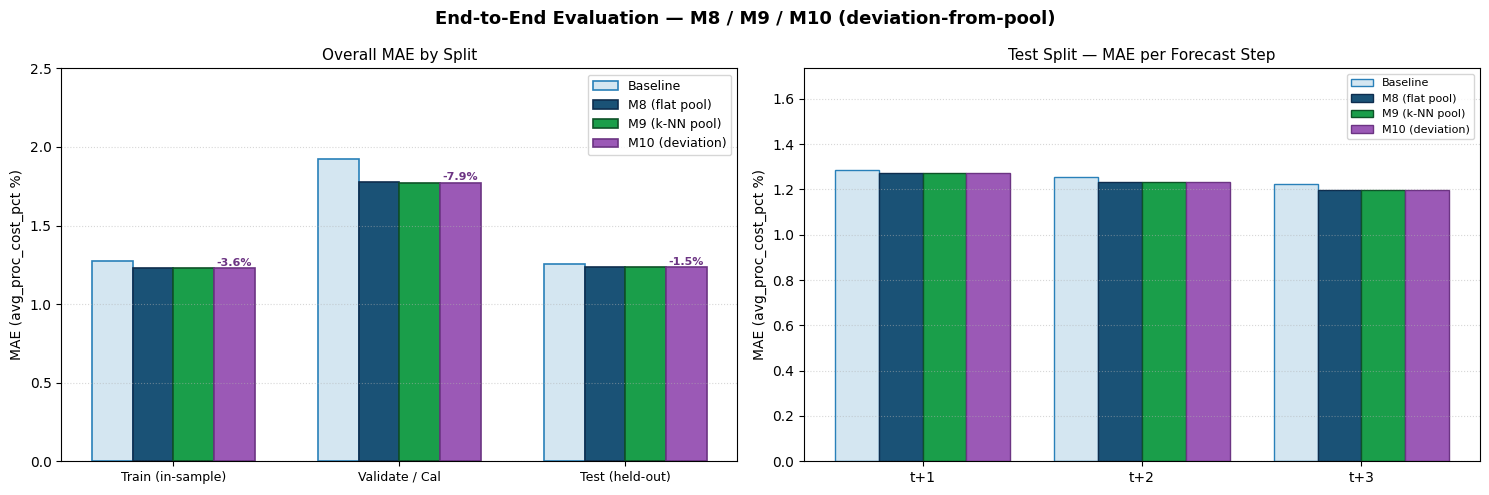

In [23]:
# In-sample predictions for all models
tr_preds     = np.zeros_like(y_tr, dtype=float)
tr_preds_knn = np.zeros_like(y_tr, dtype=float)
tr_preds_dev = np.zeros_like(y_tr, dtype=float)
for h in range(3):
    tr_preds[:, h]     = models_ci[h].predict(X_tr)
    tr_preds_knn[:, h] = models_knn[h].predict(X_tr_knn)
    # M10: predict deviation, add back pool mean
    tr_preds_dev[:, h] = models_dev[h].predict(X_tr_dev) + pool_tr_dev

# Baseline predictions for each split (flat context mean)
base_tr_preds  = np.array([[np.mean(s['context_data']['avg_proc_cost_pct'].values)] * 3 for s in train_ci])
base_cal_preds = np.array([[np.mean(s['context_data']['avg_proc_cost_pct'].values)] * 3 for s in cal_ci])
base_te_preds  = np.array([[np.mean(s['context_data']['avg_proc_cost_pct'].values)] * 3 for s in test_ci])

splits = [
    ('Train (in-sample)', y_tr,  tr_preds,  tr_preds_knn,  tr_preds_dev,  base_tr_preds,
     f'train merchants, horizon < {_cal_year}'),
    ('Validate / Cal',    y_cal, cal_preds, cal_preds_knn, cal_preds_dev, base_cal_preds,
     f'validate merchants, horizon == {_cal_year}'),
    ('Test (held-out)',   y_te,  te_preds,  te_preds_knn,  te_preds_dev,  base_te_preds,
     f'test merchants, horizon == {_test_year}'),
]

print("=" * 90)
print(f"{'End-to-End Evaluation':^90}")
print("=" * 90)

rows = []
for label, y, preds_m8, preds_m9, preds_m10, base, note in splits:
    base_mae = float(np.mean(np.abs(y - base)))
    m8_mae   = float(np.mean(np.abs(y - preds_m8)))
    m9_mae   = float(np.mean(np.abs(y - preds_m9)))
    m10_mae  = float(np.mean(np.abs(y - preds_m10)))
    m8_impr  = (m8_mae  - base_mae) / base_mae * 100
    m9_impr  = (m9_mae  - base_mae) / base_mae * 100
    m10_impr = (m10_mae - base_mae) / base_mae * 100
    steps_m8  = [float(np.mean(np.abs(y[:, h] - preds_m8[:, h])))  for h in range(3)]
    steps_m9  = [float(np.mean(np.abs(y[:, h] - preds_m9[:, h])))  for h in range(3)]
    steps_m10 = [float(np.mean(np.abs(y[:, h] - preds_m10[:, h]))) for h in range(3)]
    rows.append((label, note, base_mae, m8_mae, m9_mae, m10_mae,
                 m8_impr, m9_impr, m10_impr, steps_m8, steps_m9, steps_m10))

    print(f"\n{label}  ({note})  n={len(y):,}")
    print(f"  Baseline={base_mae:.4f}  "
          f"M8={m8_mae:.4f} ({m8_impr:+.2f}% {'✓' if m8_mae < base_mae else '✗'})  "
          f"M9={m9_mae:.4f} ({m9_impr:+.2f}% {'✓' if m9_mae < base_mae else '✗'})  "
          f"M10={m10_mae:.4f} ({m10_impr:+.2f}% {'✓' if m10_mae < base_mae else '✗'})")
    best = min(m8_mae, m9_mae, m10_mae)
    winner = 'M8' if best == m8_mae else ('M9' if best == m9_mae else 'M10')
    print(f"  Best model: {winner}  |  "
          f"M10 vs M9: {(m10_mae - m9_mae)/m9_mae*100:+.2f}%  "
          f"M10 vs M8: {(m10_mae - m8_mae)/m8_mae*100:+.2f}%")
    print(f"  M8  per step: t+1={steps_m8[0]:.4f}  t+2={steps_m8[1]:.4f}  t+3={steps_m8[2]:.4f}")
    print(f"  M9  per step: t+1={steps_m9[0]:.4f}  t+2={steps_m9[1]:.4f}  t+3={steps_m9[2]:.4f}")
    print(f"  M10 per step: t+1={steps_m10[0]:.4f}  t+2={steps_m10[1]:.4f}  t+3={steps_m10[2]:.4f}")

print(f"\n{'='*90}")
print(f"  CV   M8={avg_m8:.6f}  M9={avg_m9:.6f}  M10={avg_m10:.6f}")
print(f"  Val  M8={rows[1][3]:.6f}  M9={rows[1][4]:.6f}  M10={rows[1][5]:.6f}")
print(f"  Test M8={rows[2][3]:.6f}  M9={rows[2][4]:.6f}  M10={rows[2][5]:.6f}")
print("=" * 90)

# ── Chart ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('End-to-End Evaluation — M8 / M9 / M10 (deviation-from-pool)',
             fontsize=13, fontweight='bold')

x      = np.arange(len(rows))
bar_w  = 0.18

bars_b   = ax1.bar(x - 1.5*bar_w, [r[2] for r in rows], bar_w, label='Baseline',
                   color='#d4e6f1', edgecolor='#2980b9', linewidth=1.2)
bars_m8  = ax1.bar(x - 0.5*bar_w, [r[3] for r in rows], bar_w, label='M8 (flat pool)',
                   color='#1a5276', edgecolor='#0e2d4e', linewidth=1.2)
bars_m9  = ax1.bar(x + 0.5*bar_w, [r[4] for r in rows], bar_w, label='M9 (k-NN pool)',
                   color='#1a9e4a', edgecolor='#0e5228', linewidth=1.2)
bars_m10 = ax1.bar(x + 1.5*bar_w, [r[5] for r in rows], bar_w, label='M10 (deviation)',
                   color='#9b59b6', edgecolor='#6c3483', linewidth=1.2)

for bar, r in zip(bars_m10, rows):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
             f'{r[8]:+.1f}%', ha='center', va='bottom', fontsize=8,
             color='#6c3483', fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels([r[0] for r in rows], fontsize=9)
ax1.set_ylabel('MAE (avg_proc_cost_pct %)', fontsize=10)
ax1.set_title('Overall MAE by Split', fontsize=11)
ax1.legend(fontsize=9)
ax1.set_ylim(0, max(r[2] for r in rows) * 1.3)
ax1.grid(axis='y', linestyle=':', alpha=0.5)

# Per-step comparison on test split
steps_b    = [float(np.mean(np.abs(y_te[:, h] - base_te_preds[:, h]))) for h in range(3)]
steps_m8t  = rows[2][9]
steps_m9t  = rows[2][10]
steps_m10t = rows[2][11]
x2   = np.arange(3)
bw   = 0.2
ax2.bar(x2 - 1.5*bw, steps_b,    bw, label='Baseline',       color='#d4e6f1', edgecolor='#2980b9', linewidth=1.0)
ax2.bar(x2 - 0.5*bw, steps_m8t,  bw, label='M8 (flat pool)', color='#1a5276', edgecolor='#0e2d4e', linewidth=1.0)
ax2.bar(x2 + 0.5*bw, steps_m9t,  bw, label='M9 (k-NN pool)', color='#1a9e4a', edgecolor='#0e5228', linewidth=1.0)
ax2.bar(x2 + 1.5*bw, steps_m10t, bw, label='M10 (deviation)', color='#9b59b6', edgecolor='#6c3483', linewidth=1.0)
ax2.set_xticks(x2)
ax2.set_xticklabels(['t+1', 't+2', 't+3'], fontsize=10)
ax2.set_ylabel('MAE (avg_proc_cost_pct %)', fontsize=10)
ax2.set_title('Test Split — MAE per Forecast Step', fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(axis='y', linestyle=':', alpha=0.5)
ax2.set_ylim(0, max(steps_b) * 1.35)

plt.tight_layout()
plt.show()


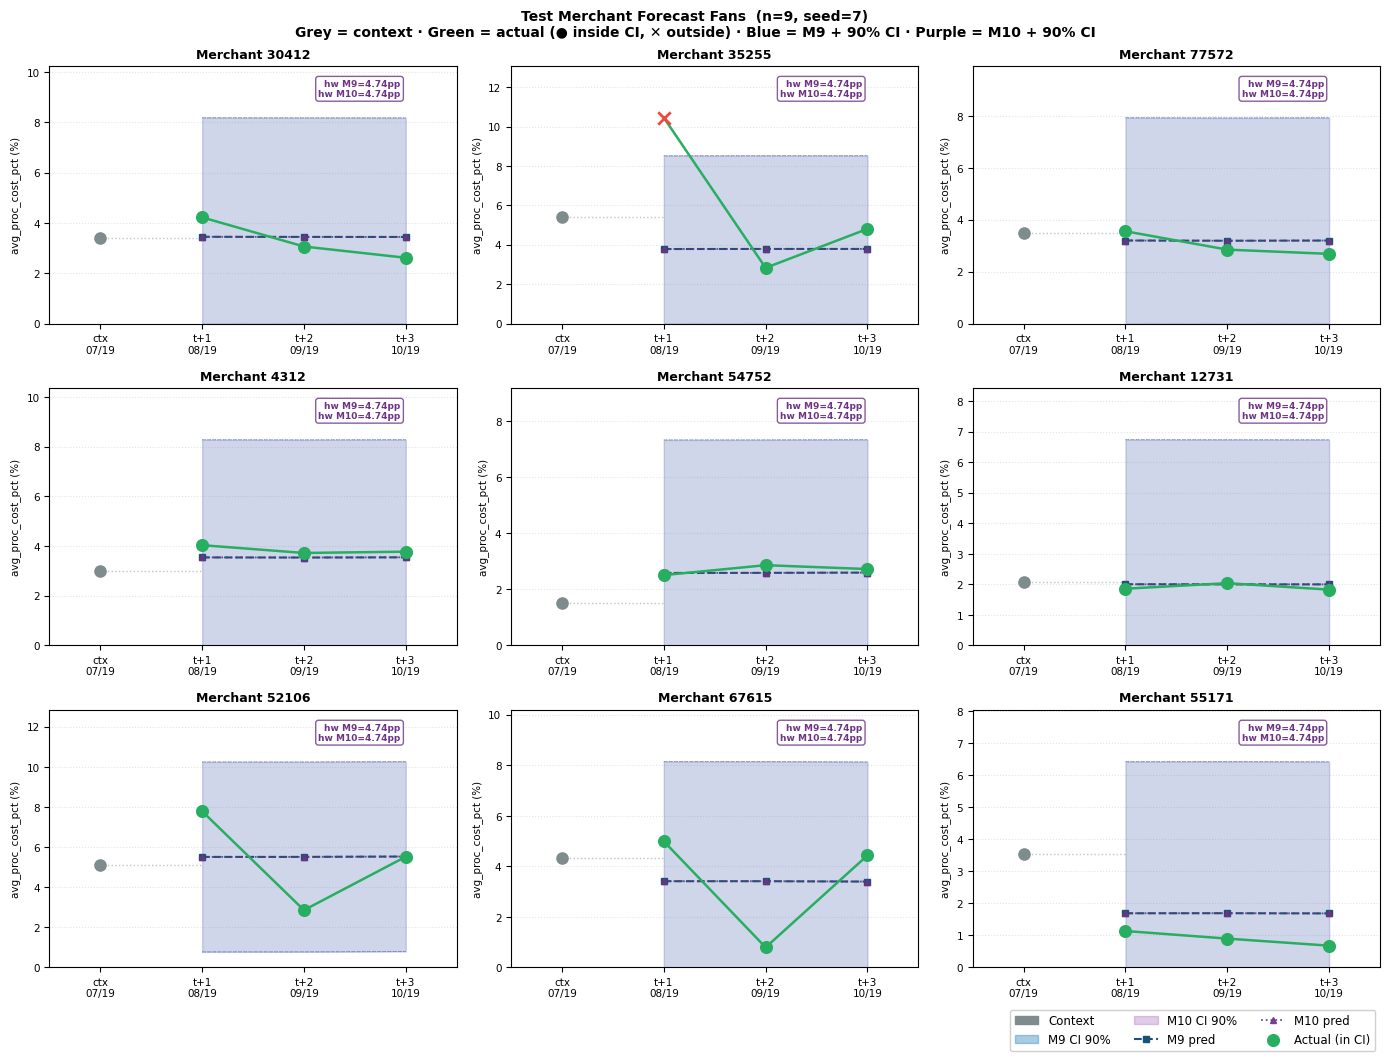

In [24]:
# ── Sample merchant forecast fans ─────────────────────────────────────────────
# For each sampled test merchant: pick their most recent test scenario, then
# plot context anchor → 3-step forecast with actuals, M9/M10 predictions, and
# M9 conformal interval band.

_SAMPLE_N  = 9
_VIS_SEED  = 7

# Build lookup: merchant → (context_end_key, scenario_idx)
_mid_to_last: dict = {}
for _idx, _s in enumerate(test_ci):
    _mid  = int(_s['merchant_id'])
    _ckey = _s['context_range'][1]   # (year, month)
    if _mid not in _mid_to_last or _ckey > _mid_to_last[_mid][0]:
        _mid_to_last[_mid] = (_ckey, _idx)

_all_vis_mids = list(_mid_to_last.keys())
_rng_vis      = np.random.default_rng(_VIS_SEED)
_perm_vis     = _rng_vis.permutation(len(_all_vis_mids))
_sample_mids  = [_all_vis_mids[i] for i in _perm_vis[:_SAMPLE_N]]

# ── Plot ──────────────────────────────────────────────────────────────────────
ncols = 3
nrows = math.ceil(_SAMPLE_N / ncols)
x_step = np.array([1, 2, 3])

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.6), squeeze=False)
fig.suptitle(
    f'Test Merchant Forecast Fans  (n={_SAMPLE_N}, seed={_VIS_SEED})\n'
    'Grey = context · Green = actual (● inside CI, ✕ outside) · '
    'Blue = M9 + 90% CI · Purple = M10 + 90% CI',
    fontsize=10, fontweight='bold'
)

for _plot_i, _mid in enumerate(_sample_mids):
    _row, _col = divmod(_plot_i, ncols)
    ax = axes[_row][_col]

    _, _idx = _mid_to_last[_mid]
    _s      = test_ci[_idx]

    ctx_val  = float(_s['context_data']['avg_proc_cost_pct'].values[-1])
    act      = y_te[_idx]
    pred_m9  = te_preds_knn[_idx]
    lo_m9    = lo_pool_knn[_idx]
    hi_m9    = hi_pool_knn[_idx]
    pred_m10 = te_preds_dev[_idx]
    lo_m10   = lo_pool_dev[_idx]
    hi_m10   = hi_pool_dev[_idx]

    _cy, _cm = _s['context_range'][1]
    _h_dates = [
        (int(_s['horizon_data'].iloc[h]['year']),
         int(_s['horizon_data'].iloc[h]['month']))
        for h in range(3)
    ]
    x_labels = (
        [f"ctx\n{_cm:02d}/{_cy % 100:02d}"] +
        [f"t+{h+1}\n{_hm:02d}/{_hy % 100:02d}" for h, (_hy, _hm) in enumerate(_h_dates)]
    )

    # Context anchor
    ax.scatter([0], [ctx_val], color='#7f8c8d', s=65, zorder=6)
    ax.plot([0, 1], [ctx_val, ctx_val], color='#7f8c8d', linestyle=':', linewidth=1, alpha=0.5)

    # M9: CI band + prediction
    ax.fill_between(x_step, lo_m9, hi_m9, alpha=0.18, color='#2980b9', zorder=2)
    ax.plot(x_step, lo_m9, '--', color='#2980b9', linewidth=0.7, alpha=0.5)
    ax.plot(x_step, hi_m9, '--', color='#2980b9', linewidth=0.7, alpha=0.5)
    ax.plot(x_step, pred_m9, 's--', color='#1a5276', linewidth=1.5, markersize=5, zorder=5,
            label='M9 pred')

    # M10: CI band + prediction
    ax.fill_between(x_step, lo_m10, hi_m10, alpha=0.12, color='#9b59b6', zorder=2)
    ax.plot(x_step, lo_m10, ':', color='#9b59b6', linewidth=0.7, alpha=0.5)
    ax.plot(x_step, hi_m10, ':', color='#9b59b6', linewidth=0.7, alpha=0.5)
    ax.plot(x_step, pred_m10, '^:', color='#6c3483', linewidth=1.3, markersize=4, zorder=5,
            alpha=0.9, label='M10 pred')

    # Actuals — coloured by whether they're inside the M9 CI
    ax.plot(x_step, act, '-', color='#27ae60', linewidth=1.8, zorder=7)
    for h in range(3):
        _inside = lo_m9[h] <= act[h] <= hi_m9[h]
        ax.scatter([x_step[h]], [act[h]],
                   marker='o' if _inside else 'x',
                   color='#27ae60' if _inside else '#e74c3c',
                   s=55 if _inside else 80, zorder=8, linewidths=2,
                   label=('Actual (in CI)' if _inside else 'Actual (out CI)') if h == 0 else None)

    ax.set_xticks([0] + list(x_step))
    ax.set_xticklabels(x_labels, fontsize=7.5)
    ax.set_title(f'Merchant {_mid}', fontsize=9, fontweight='bold')
    ax.set_ylabel('avg_proc_cost_pct (%)', fontsize=7.5)
    ax.yaxis.set_tick_params(labelsize=7.5)
    ax.grid(axis='y', linestyle=':', alpha=0.35)
    ax.set_ylim(0,max(act.max(), hi_m10.max()) * 1.25)
    ax.set_xlim(-0.5, 3.5)
    
    # show half-width in graph for quick reference
    ax.text(2.95, ax.get_ylim()[1]*0.95, f"hw M9={float(np.mean(hi_m9 - pred_m9)):.2f}pp\n"
                                        f"hw M10={float(np.mean(hi_m10 - pred_m10)):.2f}pp",
            ha='right', va='top', fontsize=6.5, color='#6c3483', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='#6c3483'))

# Shared legend from first subplot
_handles, _labels = axes[0][0].get_legend_handles_labels()
# Deduplicate
_seen, _h_uniq, _l_uniq = set(), [], []
for _h, _l in zip(_handles, _labels):
    if _l not in _seen:
        _seen.add(_l); _h_uniq.append(_h); _l_uniq.append(_l)

# Add context manually
_ctx_patch = mpatches.Patch(color='#7f8c8d', label='Context')
_m9ci_patch = mpatches.Patch(color='#2980b9', alpha=0.4, label='M9 CI 90%')
_m10ci_patch = mpatches.Patch(color='#9b59b6', alpha=0.3, label='M10 CI 90%')
_h_uniq = [_ctx_patch, _m9ci_patch, _m10ci_patch] + _h_uniq
_l_uniq = ['Context', 'M9 CI 90%', 'M10 CI 90%'] + _l_uniq

# Hide unused subplots
for _plot_i in range(_SAMPLE_N, nrows * ncols):
    _row, _col = divmod(_plot_i, ncols)
    axes[_row][_col].set_visible(False)

fig.legend(_h_uniq, _l_uniq, loc='lower right', fontsize=8.5, ncol=3,
           bbox_to_anchor=(0.99, 0.01), framealpha=0.92)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


Feature variance in training data (context_len=1 effect)
────────────────────────────────────────────────────────────
  context_mean        variance = 31.062297
  context_std         variance = 11.002857
  momentum            variance = 14.201488
  pool_mean           variance = 0.000699


══════════════════════════════════════════════════════════════
  M8 (flat pool)
══════════════════════════════════════════════════════════════
  Feature                    t+1         t+2         t+3  notes
  ──────────────────────────────────────────────────────────
  context_mean            5.9108      5.8874      5.8879
  context_std            -1.5105     -1.4583     -1.4344
  momentum               -0.0105     -0.0124     -0.0356
  pool_mean              -0.0066     -0.0074     -0.0068
  intercept               4.2586      4.2628      4.2697
  (Scaled coefficients — units are in standardised feature space)

  Effective terms (original units, ignoring zero-variance features):
    t+1: +1.0605·con

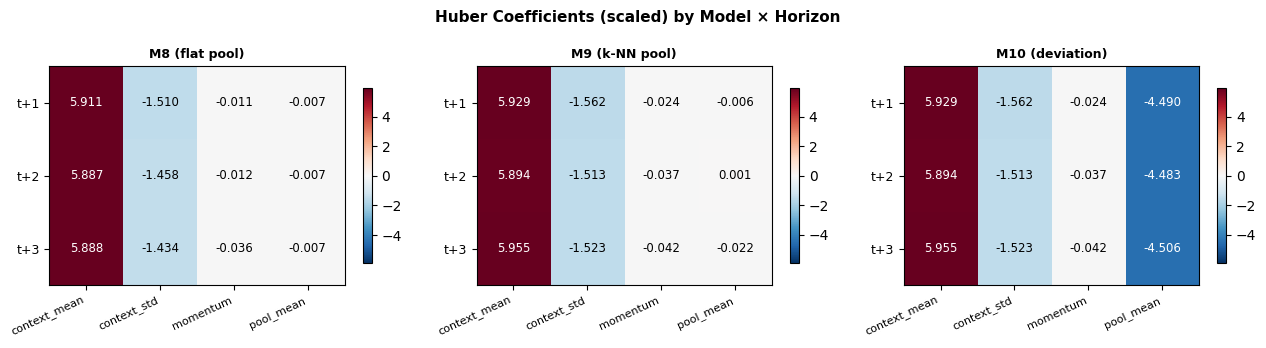


Diagnosis
────────────────────────────────────────────────────────────
• context_std and momentum are permanently 0 with context_len=1.
  The model operates on just 2 real features: context_mean + pool_mean.

• Flat predictions: each horizon model learns similar α/β weights,
  so t+1, t+2, t+3 predictions are nearly identical (no trend encoded).

• Conservative CIs: calibrated on 2018 (validate set) where costs were
  structurally elevated → residuals were large → q90 is wide for all years.

• Fix for flatness:  increase context_len ≥ 3 to activate context_std
  and momentum as real signals, enabling the model to learn cost trends.


In [25]:
# ── Huber coefficient inspection ─────────────────────────────────────────────
# With context_len=1:
#   context_std  = std([single value]) = 0  for EVERY scenario
#   momentum     = val - mean([val])   = 0  for EVERY scenario
# These two features are zero-variance — StandardScaler leaves them as 0
# after transform. They contribute nothing to predictions.
# Effectively the model is:  ŷ = α·context_mean + β·pool_mean + intercept

print("Feature variance in training data (context_len=1 effect)")
print("─" * 60)
feat_var_m8 = X_tr_raw.var(axis=0)
for fname, var in zip(FEAT_NAMES_M8, feat_var_m8):
    flag = "  ← always 0!" if var < 1e-10 else ""
    print(f"  {fname:<18}  variance = {var:.6f}{flag}")

print()

# ── Coefficient tables ────────────────────────────────────────────────────────
model_groups = [
    ('M8 (flat pool)',  models_ci,  scaler_ci),
    ('M9 (k-NN pool)',  models_knn, scaler_knn),
    ('M10 (deviation)', models_dev, scaler_dev),
]

for model_label, model_list, scaler in model_groups:
    print(f"\n{'═'*62}")
    print(f"  {model_label}")
    print(f"{'═'*62}")

    # Column header
    hdr = f"  {'Feature':<18}" + "".join(f"  {'t+'+str(h+1):>10}" for h in range(3)) + "  notes"
    print(hdr)
    print("  " + "─" * 58)

    # Scaled coefficients (what the model actually operates on)
    coef_matrix = np.array([m.coef_ for m in model_list])     # (3, 4)
    intercepts  = np.array([m.intercept_ for m in model_list]) # (3,)

    for f_idx, fname in enumerate(FEAT_NAMES_M8):
        row = f"  {fname:<18}" + "".join(f"  {coef_matrix[h, f_idx]:>10.4f}" for h in range(3))
        if feat_var_m8[f_idx] < 1e-10:
            row += "  (zero-variance feature)"
        print(row)

    row = f"  {'intercept':<18}" + "".join(f"  {intercepts[h]:>10.4f}" for h in range(3))
    print(row)
    print("  (Scaled coefficients — units are in standardised feature space)")

    # Back-transform to original units for the two effective features
    # coef_raw[f] = coef_scaled[f] / scale[f]
    # context_mean and pool_mean are indices 0 and 3
    scale = scaler.scale_     # (4,)
    mean_ = scaler.mean_      # (4,)
    coef_raw = coef_matrix / scale[None, :]   # (3, 4)

    print()
    print(f"  Effective terms (original units, ignoring zero-variance features):")
    for h in range(3):
        # ŷ = coef_raw[0]*context_mean + coef_raw[3]*pool_mean + adj_intercept
        a  = coef_raw[h, 0]   # context_mean coefficient
        b  = coef_raw[h, 3]   # pool_mean coefficient
        c  = (model_list[h].intercept_
              - (coef_matrix[h] * mean_ / scale).sum())  # adjusted intercept
        print(f"    t+{h+1}: {a:+.4f}·context_mean  {b:+.4f}·pool_mean  {c:+.4f}  "
              f"(sum of weights = {a+b:.4f})")

# ── Coefficient heatmap ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
fig.suptitle("Huber Coefficients (scaled) by Model × Horizon",
             fontsize=11, fontweight='bold')

cmap = plt.cm.RdBu_r
for ax, (mlabel, mlist, _) in zip(axes, model_groups):
    coef_mat = np.array([m.coef_ for m in mlist])  # (3, 4): rows=horizon, cols=features
    vmax = np.abs(coef_mat).max()
    im = ax.imshow(coef_mat, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(4))
    ax.set_xticklabels(FEAT_NAMES_M8, fontsize=8, rotation=25, ha='right')
    ax.set_yticks(range(3))
    ax.set_yticklabels(['t+1', 't+2', 't+3'], fontsize=9)
    ax.set_title(mlabel, fontsize=9, fontweight='bold')
    for hi in range(3):
        for fi in range(4):
            ax.text(fi, hi, f'{coef_mat[hi, fi]:.3f}',
                    ha='center', va='center', fontsize=8.5,
                    color='white' if abs(coef_mat[hi, fi]) > vmax * 0.5 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

# ── Diagnosis summary ─────────────────────────────────────────────────────────
print()
print("Diagnosis")
print("─" * 60)
print("• context_std and momentum are permanently 0 with context_len=1.")
print("  The model operates on just 2 real features: context_mean + pool_mean.")
print()
print("• Flat predictions: each horizon model learns similar α/β weights,")
print("  so t+1, t+2, t+3 predictions are nearly identical (no trend encoded).")
print()
print("• Conservative CIs: calibrated on 2018 (validate set) where costs were")
print("  structurally elevated → residuals were large → q90 is wide for all years.")
print()
print("• Fix for flatness:  increase context_len ≥ 3 to activate context_std")
print("  and momentum as real signals, enabling the model to learn cost trends.")


## 11. Coverage Level Sweep

Sweep the target coverage level from 50% to 95% and record achieved joint coverage and average interval width on `test_ci`. A well-calibrated model should track the nominal line closely.


  M8 (flat)  50%  →  joint=0.489  hw=±0.9709
  M8 (flat)  60%  →  joint=0.586  hw=±1.2499
  M8 (flat)  70%  →  joint=0.684  hw=±1.6549
  M8 (flat)  80%  →  joint=0.799  hw=±2.5253
  M8 (flat)  90%  →  joint=0.906  hw=±4.7388
  M8 (flat)  95%  →  joint=0.937  hw=±7.7668
  M9 (k-NN)  50%  →  joint=0.489  hw=±0.9675
  M9 (k-NN)  60%  →  joint=0.580  hw=±1.2368
  M9 (k-NN)  70%  →  joint=0.679  hw=±1.6353
  M9 (k-NN)  80%  →  joint=0.799  hw=±2.5292
  M9 (k-NN)  90%  →  joint=0.906  hw=±4.7362
  M9 (k-NN)  95%  →  joint=0.937  hw=±7.8093
  M10 (dev)  50%  →  joint=0.489  hw=±0.9675
  M10 (dev)  60%  →  joint=0.580  hw=±1.2368
  M10 (dev)  70%  →  joint=0.679  hw=±1.6353
  M10 (dev)  80%  →  joint=0.799  hw=±2.5292
  M10 (dev)  90%  →  joint=0.906  hw=±4.7362
  M10 (dev)  95%  →  joint=0.937  hw=±7.8092


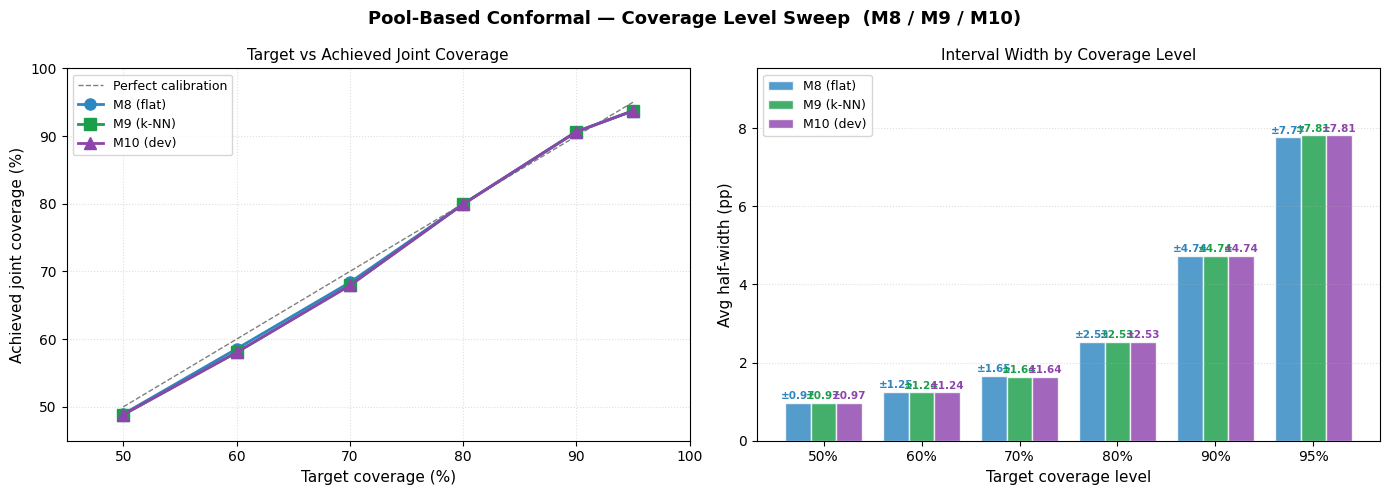

In [26]:

LEVELS = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

_model_cfgs = [
    ('M8 (flat)',  merchant_cal_res,     cal_max_res_raw,  te_preds),
    ('M9 (k-NN)', merchant_cal_res_knn,  cal_max_res_knn,  te_preds_knn),
    ('M10 (dev)',  merchant_cal_res_dev,  cal_max_res_dev,  te_preds_dev),
]

all_sweep = {}   # model_label -> list of dicts

for m_label, cal_res_map, global_res, preds_m in _model_cfgs:
    results = []
    for target in LEVELS:
        hw_sw = np.zeros(len(test_ci))
        for i, s in enumerate(test_ci):
            yr, mo    = s['context_range'][1]
            peer_mids = set(int(p) for p in
                            generate_pool(df_5411_sample, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
            peer_res  = [r for peer in peer_mids for r in cal_res_map.get(peer, [])]

            n     = len(peer_res)
            level = math.ceil((n + 1) * target) / n if n >= MIN_POOL else None
            if level is not None and level <= 1.0:
                hw_sw[i] = float(np.quantile(peer_res, level))
            else:
                gl       = math.ceil((len(global_res) + 1) * target) / len(global_res)
                hw_sw[i] = float(np.quantile(global_res, min(gl, 1.0)))

        in_sw    = (y_te >= preds_m - hw_sw[:, None]) & (y_te <= preds_m + hw_sw[:, None])
        joint_sw = float(np.mean(in_sw.all(axis=1)))
        avg_hw   = float(np.mean(hw_sw))
        results.append({'target': target, 'joint_cov': joint_sw, 'avg_hw': avg_hw})
        print(f"  {m_label}  {target*100:.0f}%  →  joint={joint_sw:.3f}  hw=±{avg_hw:.4f}")

    all_sweep[m_label] = results

# ── Chart ─────────────────────────────────────────────────────────────────────
_colours = {'M8 (flat)': '#2e86c1', 'M9 (k-NN)': '#1a9e4a', 'M10 (dev)': '#8e44ad'}
_markers = {'M8 (flat)': 'o', 'M9 (k-NN)': 's', 'M10 (dev)': '^'}
_bar_w   = 0.26
_x       = np.arange(len(LEVELS))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pool-Based Conformal — Coverage Level Sweep  (M8 / M9 / M10)',
             fontsize=13, fontweight='bold')

# Panel 1: target vs achieved joint coverage
ax1.plot([50, 95], [50, 95], 'k--', linewidth=1, alpha=0.5, label='Perfect calibration')
for m_label, results in all_sweep.items():
    targets_l = [r['target']    for r in results]
    covs_l    = [r['joint_cov'] for r in results]
    ax1.plot([t * 100 for t in targets_l], [c * 100 for c in covs_l],
             marker=_markers[m_label], linewidth=2, color=_colours[m_label],
             markersize=8, label=m_label)
ax1.set_xlabel('Target coverage (%)', fontsize=11)
ax1.set_ylabel('Achieved joint coverage (%)', fontsize=11)
ax1.set_title('Target vs Achieved Joint Coverage', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(linestyle=':', alpha=0.4)
ax1.set_xlim(45, 100); ax1.set_ylim(45, 100)

# Panel 2: avg half-width by coverage level (grouped bars)
for k, (m_label, results) in enumerate(all_sweep.items()):
    hws_l = [r['avg_hw'] for r in results]
    offset = (k - 1) * _bar_w
    bars = ax2.bar(_x + offset, hws_l, width=_bar_w,
                   color=_colours[m_label], alpha=0.82, edgecolor='white', label=m_label)
    for bar, hw in zip(bars, hws_l):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
                 f'±{hw:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold',
                 color=_colours[m_label])

ax2.set_xticks(_x)
ax2.set_xticklabels([f'{int(t*100)}%' for t in LEVELS])
ax2.set_xlabel('Target coverage level', fontsize=11)
ax2.set_ylabel('Avg half-width (pp)', fontsize=11)
ax2.set_title('Interval Width by Coverage Level', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle=':', alpha=0.4)
max_hw = max(r['avg_hw'] for res in all_sweep.values() for r in res)
ax2.set_ylim(0, max_hw * 1.22)

plt.tight_layout()
plt.show()


In [27]:
# get actual variance of the merchants at each coverage level to compare against the avg half-widths

print("\nActual variance of test merchants at each coverage level:")
print("─" * 60)
for m_label, results in all_sweep.items():
    print(f"\n{m_label}")
    for r in results:
        target = r['target']
        hw_sw = np.zeros(len(test_ci))
        for i, s in enumerate(test_ci):
            yr, mo    = s['context_range'][1]
            peer_mids = set(int(p) for p in
                            generate_pool(df_5411_sample, int(s['merchant_id']), yr, mo)['merchant_id'].unique())
            peer_res  = [r for peer in peer_mids for r in cal_res_map.get(peer, [])]

            n     = len(peer_res)
            level = math.ceil((n + 1) * target) / n if n >= MIN_POOL else None
            if level is not None and level <= 1.0:
                hw_sw[i] = float(np.quantile(peer_res, level))
            else:
                gl       = math.ceil((len(global_res) + 1) * target) / len(global_res)
                hw_sw[i] = float(np.quantile(global_res, min(gl, 1.0)))

        # Calculate actual variance of test merchants within the interval defined by hw_sw
        lower_bounds = preds_m - hw_sw[:, None]
        upper_bounds = preds_m + hw_sw[:, None]
        in_interval = (y_te >= lower_bounds) & (y_te <= upper_bounds)
        variance_within_interval = np.var(y_te[in_interval.all(axis=1)], axis=0)
        print(f"  Target {int(target*100)}%: Variance within interval = {variance_within_interval}")
        
        # find degree of actual conservatism by comparing variance_within_interval to avg_hw
        conservatism_factor = variance_within_interval / (r['avg_hw'] ** 2)
        # conservatism_factor is a 3-element array (t+1, t+2, t+3), so format element-wise
        print(
            "    Conservatism factor (variance / hw^2): "
            f"t+1={conservatism_factor[0]:.2f}, "
            f"t+2={conservatism_factor[1]:.2f}, "
            f"t+3={conservatism_factor[2]:.2f}, "
            f"avg={np.mean(conservatism_factor):.2f}"
        )
        
        



Actual variance of test merchants at each coverage level:
────────────────────────────────────────────────────────────

M8 (flat)
  Target 50%: Variance within interval = [1.23744126 1.23060809 1.24043599]
    Conservatism factor (variance / hw^2): t+1=1.31, t+2=1.31, t+3=1.32, avg=1.31
  Target 60%: Variance within interval = [1.31584447 1.31201909 1.33399731]
    Conservatism factor (variance / hw^2): t+1=0.84, t+2=0.84, t+3=0.85, avg=0.85
  Target 70%: Variance within interval = [1.79051473 1.86762498 1.81604944]
    Conservatism factor (variance / hw^2): t+1=0.65, t+2=0.68, t+3=0.66, avg=0.67
  Target 80%: Variance within interval = [2.36475451 2.50436723 2.33873725]
    Conservatism factor (variance / hw^2): t+1=0.37, t+2=0.39, t+3=0.37, avg=0.38
  Target 90%: Variance within interval = [4.16622609 4.07669938 3.9820676 ]
    Conservatism factor (variance / hw^2): t+1=0.19, t+2=0.18, t+3=0.18, avg=0.18
  Target 95%: Variance within interval = [5.67393021 6.34467309 5.99188402]
   

## 12. Risk Model Diagnostics

This section investigates whether the GBR residual-risk model trained on 2018 calibration data generalises to 2019 test data, and whether the deployed `low-mid-high_50_85` scheme is correctly calibrated.

| Cell | Purpose |
|---|---|
| Drift diagnostic | Spearman rank correlation — does the 2018 risk ranking still order 2019 residuals? |
| Drift decomposition | Separates score-mass shift from tail-severity shift |
| Learned vs CoV | Compares residual-risk (GBR) ranking against simple CoV ranking on holdout + test |
| Top-band salvage | Quantifies extra width needed in highest-risk band to hit 90% coverage |
| Deployment explainer | Breaks down the active guard decision in plain numbers |
| Pre-guard snapshot | Shows per-model holdout vs test coverage before the guard fires |
| Miss breakdown | Diagnoses which volatility band drives coverage failures on 2019 test |

**Key finding:** The Low band absorbs ~35 extra misses on 2019 test relative to 2018 holdout.  
Cause: peer-pool features (`pool_mean_gap_ratio`, `ctx_to_knn_gap_ratio`) pull Low-band merchants into tighter quantile widths. Section 13 tests dropping those features.

In [28]:
# Drift diagnostic: does the 2018 residual-risk ranking still order 2019 correctly?
import numpy as np
import pandas as pd


def _rankdata_avg(a):
    a = np.asarray(a, dtype=float)
    order = np.argsort(a, kind='mergesort')
    ranks = np.empty(len(a), dtype=float)
    sorted_a = a[order]
    i = 0
    while i < len(a):
        j = i + 1
        while j < len(a) and sorted_a[j] == sorted_a[i]:
            j += 1
        avg_rank = 0.5 * (i + j - 1) + 1.0
        ranks[order[i:j]] = avg_rank
        i = j
    return ranks


def _spearman_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]
    if len(x) < 3:
        return np.nan
    rx = _rankdata_avg(x)
    ry = _rankdata_avg(y)
    sx = rx.std(ddof=0)
    sy = ry.std(ddof=0)
    if sx == 0 or sy == 0:
        return np.nan
    return float(np.corrcoef(rx, ry)[0, 1])


def _bucket_profile(scores, actual, edges, label):
    bins = np.digitize(scores, edges[1:-1], right=False)
    rows = []
    for b in range(len(edges) - 1):
        mask = bins == b
        if not mask.any():
            continue
        rows.append({
            'split': label,
            'bin': b,
            'n': int(mask.sum()),
            'score_lo': float(edges[b]),
            'score_hi': float(edges[b + 1]),
            'mean_score': float(np.mean(scores[mask])),
            'mean_actual': float(np.mean(actual[mask])),
            'median_actual': float(np.median(actual[mask])),
            'p90_actual': float(np.quantile(actual[mask], 0.90)),
        })
    return pd.DataFrame(rows)


def _top_bottom_lift(scores, actual, top_frac=0.2):
    n = len(scores)
    k = max(1, int(np.ceil(top_frac * n)))
    order = np.argsort(scores)
    low_idx = order[:k]
    high_idx = order[-k:]
    return {
        'n_group': int(k),
        'low_mean_actual': float(np.mean(actual[low_idx])),
        'high_mean_actual': float(np.mean(actual[high_idx])),
        'lift_ratio': float(np.mean(actual[high_idx]) / (np.mean(actual[low_idx]) + 1e-12)),
        'lift_diff': float(np.mean(actual[high_idx]) - np.mean(actual[low_idx])),
    }


# Compare the honest 2018 holdout (eval_mask) to 2019 test.
cal_holdout_score = np.asarray(eval_risk_score, dtype=float)
cal_holdout_actual = np.asarray(cal_max_res_knn[eval_mask], dtype=float)
te_score = np.asarray(te_risk_score, dtype=float)
te_actual = np.asarray(np.max(np.abs(y_te - te_preds_knn), axis=1), dtype=float)

# Freeze the ranking geometry using 2018 holdout percentiles, then apply to 2019 test.
profile_edges = np.quantile(cal_holdout_score, [0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
profile_edges = np.maximum.accumulate(profile_edges)
profile_edges = np.unique(profile_edges)
if len(profile_edges) < 3:
    raise ValueError('Holdout score spread is too degenerate for drift profiling.')

cal_profile = _bucket_profile(cal_holdout_score, cal_holdout_actual, profile_edges, '2018_holdout')
te_profile = _bucket_profile(te_score, te_actual, profile_edges, '2019_test')
profile = pd.concat([cal_profile, te_profile], ignore_index=True)

cal_bin_rank_corr = _spearman_corr(cal_profile['bin'].to_numpy(), cal_profile['mean_actual'].to_numpy())
te_bin_rank_corr = _spearman_corr(te_profile['bin'].to_numpy(), te_profile['mean_actual'].to_numpy())

summary = pd.DataFrame([
    {
        'split': '2018_holdout',
        'n': len(cal_holdout_score),
        'score_vs_actual_spearman': _spearman_corr(cal_holdout_score, cal_holdout_actual),
        'bin_rank_vs_mean_actual_spearman': cal_bin_rank_corr,
        **_top_bottom_lift(cal_holdout_score, cal_holdout_actual),
    },
    {
        'split': '2019_test',
        'n': len(te_score),
        'score_vs_actual_spearman': _spearman_corr(te_score, te_actual),
        'bin_rank_vs_mean_actual_spearman': te_bin_rank_corr,
        **_top_bottom_lift(te_score, te_actual),
    },
])

print('=' * 108)
print('Residual-risk drift diagnostic: 2018 holdout ranking vs 2019 test realisation (M9 / k-NN residual target)')
print('=' * 108)
print('\nSummary metrics')
display(summary.round(4))

print('\nBucket profiles using 2018 holdout score edges')
display(profile.round(4))

merged = cal_profile.merge(
    te_profile,
    on='bin',
    suffixes=('_2018_holdout', '_2019_test'),
    how='inner',
)
merged['mean_actual_diff_test_minus_holdout'] = merged['mean_actual_2019_test'] - merged['mean_actual_2018_holdout']
merged['mean_actual_ratio_test_over_holdout'] = merged['mean_actual_2019_test'] / (merged['mean_actual_2018_holdout'] + 1e-12)

print('\nSame-bin comparison: does the ordering learned on 2018 still separate 2019?')
display(
    merged[[
        'bin',
        'n_2018_holdout',
        'n_2019_test',
        'mean_score_2018_holdout',
        'mean_score_2019_test',
        'mean_actual_2018_holdout',
        'mean_actual_2019_test',
        'mean_actual_diff_test_minus_holdout',
        'mean_actual_ratio_test_over_holdout',
    ]].round(4)
)

print('\nMonotonicity checks')
print(f"2018 holdout bin-order Spearman: {cal_bin_rank_corr:.4f}")
print(f"2019 test    bin-order Spearman: {te_bin_rank_corr:.4f}")
print(f"2018 holdout top20/bottom20 actual lift ratio: {summary.loc[0, 'lift_ratio']:.4f}")
print(f"2019 test    top20/bottom20 actual lift ratio: {summary.loc[1, 'lift_ratio']:.4f}")

Residual-risk drift diagnostic: 2018 holdout ranking vs 2019 test realisation (M9 / k-NN residual target)

Summary metrics


,split,n,score_vs_actual_spearman,bin_rank_vs_mean_actual_spearman,n_group,low_mean_actual,high_mean_actual,lift_ratio,lift_diff
0,2018_holdout,511,0.5514,1.0,103,0.7171,3.4932,4.8713,2.7761
1,2019_test,1132,0.6102,1.0,227,0.8097,5.8301,7.2005,5.0204



Bucket profiles using 2018 holdout score edges


,split,bin,n,score_lo,score_hi,mean_score,mean_actual,median_actual,p90_actual
0,2018_holdout,0,102,0.2457,0.3798,0.3149,0.6842,0.4297,1.0717
1,2018_holdout,1,98,0.3798,0.4666,0.4256,0.8501,0.6242,1.6591
2,2018_holdout,2,106,0.4666,0.5620,0.5125,1.0981,0.7767,2.5433
3,2018_holdout,3,102,0.5620,0.6634,0.6046,2.1413,1.3402,4.3284
4,2018_holdout,4,103,0.6634,2.2702,0.9099,3.4932,1.7698,10.1600
5,2019_test,0,229,0.2457,0.3798,0.3115,0.8082,0.4805,1.4354
6,2019_test,1,176,0.3798,0.4666,0.4250,0.8946,0.7144,1.6049
7,2019_test,2,211,0.4666,0.5620,0.5123,1.2418,0.8875,2.6197
8,2019_test,3,217,0.5620,0.6634,0.6073,1.5904,1.2787,2.8754
9,2019_test,4,299,0.6634,2.2702,1.0192,4.9939,2.5132,12.5632



Same-bin comparison: does the ordering learned on 2018 still separate 2019?


,bin,n_2018_holdout,n_2019_test,mean_score_2018_holdout,mean_score_2019_test,mean_actual_2018_holdout,mean_actual_2019_test,mean_actual_diff_test_minus_holdout,mean_actual_ratio_test_over_holdout
0,0,102,229,0.3149,0.3115,0.6842,0.8082,0.1240,1.1813
1,1,98,176,0.4256,0.4250,0.8501,0.8946,0.0445,1.0523
2,2,106,211,0.5125,0.5123,1.0981,1.2418,0.1437,1.1309
3,3,102,217,0.6046,0.6073,2.1413,1.5904,-0.5509,0.7427
4,4,103,299,0.9099,1.0192,3.4932,4.9939,1.5007,1.4296



Monotonicity checks
2018 holdout bin-order Spearman: 1.0000
2019 test    bin-order Spearman: 1.0000
2018 holdout top20/bottom20 actual lift ratio: 4.8713
2019 test    top20/bottom20 actual lift ratio: 7.2005


In [29]:
# Follow-up: decompose drift into score-mass shift vs tail-severity shift.
cal_share = cal_profile[['bin', 'n', 'mean_actual']].copy()
cal_share['split'] = '2018_holdout'
cal_share['share'] = cal_share['n'] / cal_share['n'].sum()
cal_share['residual_mass_share'] = (cal_share['n'] * cal_share['mean_actual']) / (cal_share['n'] * cal_share['mean_actual']).sum()

te_share = te_profile[['bin', 'n', 'mean_actual']].copy()
te_share['split'] = '2019_test'
te_share['share'] = te_share['n'] / te_share['n'].sum()
te_share['residual_mass_share'] = (te_share['n'] * te_share['mean_actual']) / (te_share['n'] * te_share['mean_actual']).sum()

share_cmp = cal_share.merge(te_share, on='bin', suffixes=('_2018_holdout', '_2019_test'))
share_cmp['share_diff_test_minus_holdout'] = share_cmp['share_2019_test'] - share_cmp['share_2018_holdout']
share_cmp['residual_mass_share_diff_test_minus_holdout'] = (
    share_cmp['residual_mass_share_2019_test'] - share_cmp['residual_mass_share_2018_holdout']
)

print('\nScore-mass / residual-mass drift by 2018-defined bins')
display(
    share_cmp[[
        'bin',
        'share_2018_holdout',
        'share_2019_test',
        'share_diff_test_minus_holdout',
        'residual_mass_share_2018_holdout',
        'residual_mass_share_2019_test',
        'residual_mass_share_diff_test_minus_holdout',
    ]].round(4)
)

print('Top-bin occupancy drift: '
      f"holdout={share_cmp.loc[share_cmp['bin'] == share_cmp['bin'].max(), 'share_2018_holdout'].iloc[0]:.4f}, "
      f"test={share_cmp.loc[share_cmp['bin'] == share_cmp['bin'].max(), 'share_2019_test'].iloc[0]:.4f}")
print('Top-bin residual-mass drift: '
      f"holdout={share_cmp.loc[share_cmp['bin'] == share_cmp['bin'].max(), 'residual_mass_share_2018_holdout'].iloc[0]:.4f}, "
      f"test={share_cmp.loc[share_cmp['bin'] == share_cmp['bin'].max(), 'residual_mass_share_2019_test'].iloc[0]:.4f}")


Score-mass / residual-mass drift by 2018-defined bins


,bin,share_2018_holdout,share_2019_test,share_diff_test_minus_holdout,residual_mass_share_2018_holdout,residual_mass_share_2019_test,residual_mass_share_diff_test_minus_holdout
0,0,0.1996,0.2023,0.0027,0.0823,0.0758,-0.0066
1,1,0.1918,0.1555,-0.0363,0.0983,0.0645,-0.0338
2,2,0.2074,0.1864,-0.0210,0.1373,0.1073,-0.0300
3,3,0.1996,0.1917,-0.0079,0.2577,0.1413,-0.1164
4,4,0.2016,0.2641,0.0626,0.4244,0.6112,0.1868


Top-bin occupancy drift: holdout=0.2016, test=0.2641
Top-bin residual-mass drift: holdout=0.4244, test=0.6112


In [31]:
# ── CoV baseline scores for learned-vs-CoV comparison (Section 12) ────────────
# Simple coefficient of variation of the context window avg_proc_cost_pct —
# used as a baseline ranking signal to compare against the learned GBR residual-risk score.

def _ctx_cov(s):
    vals = s['context_data']['avg_proc_cost_pct'].values.astype(float)
    return float(np.std(vals)) / (float(np.mean(vals)) + _VOL_EPS)

cal_cv_eval = np.array([_ctx_cov(s) for s in eval_ci], dtype=float)
te_cv       = np.array([_ctx_cov(s) for s in test_ci], dtype=float)

print(f'cal_cv_eval: {cal_cv_eval.shape}  mean={cal_cv_eval.mean():.4f}  std={cal_cv_eval.std():.4f}')
print(f'te_cv:       {te_cv.shape}  mean={te_cv.mean():.4f}  std={te_cv.std():.4f}')


cal_cv_eval: (511,)  mean=0.2396  std=0.1759
te_cv:       (1132,)  mean=0.2390  std=0.1702


In [32]:
# Compare simple CoV ranking against learned residual-risk ranking on 2018 holdout and 2019 test.
import numpy as np
import pandas as pd


def _score_diagnostic_rows(score_name, holdout_score, test_score, holdout_actual, test_actual):
    return [
        {
            'score': score_name,
            'split': '2018_holdout',
            'n': len(holdout_score),
            'score_vs_actual_spearman': _spearman_corr(holdout_score, holdout_actual),
            **_top_bottom_lift(holdout_score, holdout_actual),
        },
        {
            'score': score_name,
            'split': '2019_test',
            'n': len(test_score),
            'score_vs_actual_spearman': _spearman_corr(test_score, test_actual),
            **_top_bottom_lift(test_score, test_actual),
        },
    ]


def _frozen_bin_profile(score_name, holdout_score, test_score, holdout_actual, test_actual):
    edges = np.quantile(holdout_score, [0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    edges = np.maximum.accumulate(edges)
    edges = np.unique(edges)
    if len(edges) < 3:
        raise ValueError(f'{score_name} holdout score spread is too degenerate for profiling.')
    holdout_profile = _bucket_profile(holdout_score, holdout_actual, edges, f'2018_holdout::{score_name}')
    test_profile = _bucket_profile(test_score, test_actual, edges, f'2019_test::{score_name}')
    return edges, holdout_profile, test_profile


cov_holdout_score = np.asarray(cal_cv_eval, dtype=float)
cov_test_score = np.asarray(te_cv, dtype=float)
learned_holdout_score = np.asarray(cal_holdout_score, dtype=float)
learned_test_score = np.asarray(te_score, dtype=float)

score_compare = pd.DataFrame(
    _score_diagnostic_rows('CoV_only', cov_holdout_score, cov_test_score, cal_holdout_actual, te_actual)
    + _score_diagnostic_rows('learned_risk', learned_holdout_score, learned_test_score, cal_holdout_actual, te_actual)
)

cov_edges, cov_holdout_profile, cov_test_profile = _frozen_bin_profile(
    'CoV_only', cov_holdout_score, cov_test_score, cal_holdout_actual, te_actual
)
learned_edges, learned_holdout_profile, learned_test_profile = _frozen_bin_profile(
    'learned_risk', learned_holdout_score, learned_test_score, cal_holdout_actual, te_actual
)

bin_monotonicity = pd.DataFrame([
    {
        'score': 'CoV_only',
        'holdout_bin_rank_vs_mean_actual_spearman': _spearman_corr(
            cov_holdout_profile['bin'].to_numpy(), cov_holdout_profile['mean_actual'].to_numpy()
        ),
        'test_bin_rank_vs_mean_actual_spearman': _spearman_corr(
            cov_test_profile['bin'].to_numpy(), cov_test_profile['mean_actual'].to_numpy()
        ),
    },
    {
        'score': 'learned_risk',
        'holdout_bin_rank_vs_mean_actual_spearman': _spearman_corr(
            learned_holdout_profile['bin'].to_numpy(), learned_holdout_profile['mean_actual'].to_numpy()
        ),
        'test_bin_rank_vs_mean_actual_spearman': _spearman_corr(
            learned_test_profile['bin'].to_numpy(), learned_test_profile['mean_actual'].to_numpy()
        ),
    },
])

print('=' * 112)
print('CoV-only score versus learned residual-risk score')
print('=' * 112)
print('\nScenario-level ranking quality')
display(score_compare.round(4))
print('\nBin-level monotonicity with frozen 2018 holdout quintiles')
display(bin_monotonicity.round(4))

profile_compare = pd.concat([
    cov_holdout_profile.assign(score='CoV_only'),
    cov_test_profile.assign(score='CoV_only'),
    learned_holdout_profile.assign(score='learned_risk'),
    learned_test_profile.assign(score='learned_risk'),
], ignore_index=True)
print('\nFrozen-bin profiles for both scores')
display(profile_compare.round(4))

CoV-only score versus learned residual-risk score

Scenario-level ranking quality


,score,split,n,score_vs_actual_spearman,n_group,low_mean_actual,high_mean_actual,lift_ratio,lift_diff
0,CoV_only,2018_holdout,511,0.3563,103,0.9687,2.0250,2.0905,1.0563
1,CoV_only,2019_test,1132,0.4601,227,0.9301,4.4667,4.8026,3.5366
2,learned_risk,2018_holdout,511,0.5514,103,0.7171,3.4932,4.8713,2.7761
3,learned_risk,2019_test,1132,0.6102,227,0.8097,5.8301,7.2005,5.0204



Bin-level monotonicity with frozen 2018 holdout quintiles


,score,holdout_bin_rank_vs_mean_actual_spearman,test_bin_rank_vs_mean_actual_spearman
0,CoV_only,0.9,1.0
1,learned_risk,1.0,1.0



Frozen-bin profiles for both scores


,split,bin,n,score_lo,score_hi,mean_score,mean_actual,median_actual,p90_actual,score
0,2018_holdout::CoV_only,0,102,0.0236,0.1080,0.0745,0.9609,0.5689,1.5664,CoV_only
1,2018_holdout::CoV_only,1,102,0.1080,0.1681,0.1368,1.0743,0.6647,1.7965,CoV_only
2,2018_holdout::CoV_only,2,102,0.1681,0.2342,0.1982,1.6261,0.7818,3.6140,CoV_only
3,2018_holdout::CoV_only,3,102,0.2342,0.3263,0.2701,2.6047,1.1391,5.7238,CoV_only
4,2018_holdout::CoV_only,4,103,0.3263,0.9896,0.5160,2.0250,1.2657,4.2097,CoV_only
5,2019_test::CoV_only,0,219,0.0236,0.1080,0.0760,0.9112,0.5784,1.5080,CoV_only
6,2019_test::CoV_only,1,233,0.1080,0.1681,0.1347,1.0993,0.8133,2.0160,CoV_only
7,2019_test::CoV_only,2,228,0.1681,0.2342,0.2008,1.5382,0.9441,2.8290,CoV_only
8,2019_test::CoV_only,3,209,0.2342,0.3263,0.2800,2.7468,1.6612,6.6653,CoV_only
9,2019_test::CoV_only,4,243,0.3263,0.9896,0.4864,4.3718,2.1082,11.5267,CoV_only


In [33]:
# Quantify the smallest extra width needed in the highest 2019 learned-risk band to hit target coverage.
import numpy as np
import pandas as pd


def _conformal_q(vals, fallback=None):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals) == 0:
        if fallback is None:
            raise ValueError('Cannot estimate quantile from an empty array.')
        return float(fallback)
    if 'adaptive_q' in globals():
        q = adaptive_q(vals.tolist())
        if q is not None:
            return float(q)
    level = min(0.999999, np.ceil((len(vals) + 1) * TARGET_COV) / len(vals))
    return float(np.quantile(vals, level, method='higher'))


def _effective_hw(lo, hi):
    if '_effective_half_width' in globals():
        return _effective_half_width(lo, hi)
    return (hi - lo) / 2.0


# Use the learned-risk 2018 holdout bins already defined above.
learned_test_bins = np.digitize(learned_test_score, learned_edges[1:-1], right=False)
learned_holdout_bins = np.digitize(learned_holdout_score, learned_edges[1:-1], right=False)

# Fit per-band M9 widths on 2018 holdout, then apply to 2019 test.
holdout_q_by_bin = []
for b in range(len(learned_edges) - 1):
    band_actual = cal_holdout_actual[learned_holdout_bins == b]
    holdout_q_by_bin.append(_conformal_q(band_actual, fallback=q90_global_knn))
holdout_q_by_bin = np.asarray(holdout_q_by_bin, dtype=float)
holdout_q_by_bin = np.maximum.accumulate(holdout_q_by_bin)

test_hw = holdout_q_by_bin[learned_test_bins]
base_lo = np.clip(te_preds_knn - test_hw[:, None], 0, None)
base_hi = te_preds_knn + test_hw[:, None]
base_hit = ((y_te >= base_lo) & (y_te <= base_hi)).all(axis=1)
base_joint_cov = float(np.mean(base_hit))
base_avg_hw = float(np.mean(_effective_hw(base_lo, base_hi)))

# Solve the smallest additive delta for the top bin only.
top_bin = int(learned_test_bins.max())
top_mask = learned_test_bins == top_bin
if not top_mask.any():
    raise ValueError('No test scenarios landed in the highest learned-risk band.')

top_residual = te_actual[top_mask]
needed_top_q = _conformal_q(top_residual)
current_top_q = float(holdout_q_by_bin[top_bin])
min_top_delta_for_full_top_band_90 = max(0.0, needed_top_q - current_top_q)

# Also solve the exact minimal delta needed for overall joint coverage >= TARGET_COV.
current_miss = (~base_hit).astype(int)
need_fix = max(0, int(np.ceil(TARGET_COV * len(base_hit)) - base_hit.sum()))

if need_fix == 0:
    min_top_delta_for_global_target = 0.0
else:
    top_miss_residual = te_actual[top_mask][~base_hit[top_mask]]
    if len(top_miss_residual) < need_fix:
        min_top_delta_for_global_target = np.nan
    else:
        sorted_needed = np.sort(top_miss_residual)
        required_abs_width = float(sorted_needed[need_fix - 1])
        min_top_delta_for_global_target = max(0.0, required_abs_width - current_top_q)

patched_hw = test_hw.copy()
patched_hw[top_mask] = patched_hw[top_mask] + min_top_delta_for_global_target
patched_lo = np.clip(te_preds_knn - patched_hw[:, None], 0, None)
patched_hi = te_preds_knn + patched_hw[:, None]
patched_hit = ((y_te >= patched_lo) & (y_te <= patched_hi)).all(axis=1)
patched_joint_cov = float(np.mean(patched_hit))
patched_avg_hw = float(np.mean(_effective_hw(patched_lo, patched_hi)))

baseline_lo = np.clip(te_preds_knn - hw_per_scenario_knn[:, None], 0, None)
baseline_hi = te_preds_knn + hw_per_scenario_knn[:, None]
baseline_joint_cov_test = float(np.mean(((y_te >= baseline_lo) & (y_te <= baseline_hi)).all(axis=1)))
baseline_avg_hw_test = float(np.mean(_effective_hw(baseline_lo, baseline_hi)))

salvage_summary = pd.DataFrame([
    {
        'quantity': 'current_top_band_q_from_2018_holdout',
        'value': current_top_q,
    },
    {
        'quantity': 'needed_top_band_q_for_top_band_2019_90pct',
        'value': needed_top_q,
    },
    {
        'quantity': 'extra_delta_for_top_band_2019_90pct',
        'value': min_top_delta_for_full_top_band_90,
    },
    {
        'quantity': 'extra_delta_for_overall_test_target',
        'value': min_top_delta_for_global_target,
    },
    {
        'quantity': 'current_test_joint_cov_with_frozen_bands',
        'value': base_joint_cov,
    },
    {
        'quantity': 'patched_test_joint_cov',
        'value': patched_joint_cov,
    },
    {
        'quantity': 'current_test_avg_hw_with_frozen_bands',
        'value': base_avg_hw,
    },
    {
        'quantity': 'patched_test_avg_hw',
        'value': patched_avg_hw,
    },
    {
        'quantity': 'baseline_pool_local_test_joint_cov',
        'value': baseline_joint_cov_test,
    },
    {
        'quantity': 'baseline_pool_local_test_avg_hw',
        'value': baseline_avg_hw_test,
    },
])

print('=' * 112)
print('Top-band salvage test: how much extra width would the highest 2019 learned-risk band need?')
print('=' * 112)
display(salvage_summary.round(4))

band_table = pd.DataFrame({
    'bin': np.arange(len(holdout_q_by_bin)),
    'q_from_2018_holdout': holdout_q_by_bin,
    'test_n': [(learned_test_bins == b).sum() for b in range(len(holdout_q_by_bin))],
    'test_mean_actual': [
        float(np.mean(te_actual[learned_test_bins == b])) if np.any(learned_test_bins == b) else np.nan
        for b in range(len(holdout_q_by_bin))
    ],
})
print('\nPer-band widths and 2019 realised severity')
display(band_table.round(4))

print(f'Highest learned-risk band index: {top_bin}')
print(f'Current frozen test coverage: {base_joint_cov:.4f}')
print(f'Min additive delta on highest band for overall target: {min_top_delta_for_global_target:.4f}')
print(f'Patched test coverage after top-band delta: {patched_joint_cov:.4f}')
print(f'Patched test avg half-width vs baseline pool-local: {patched_avg_hw:.4f} vs {baseline_avg_hw_test:.4f}')

Top-band salvage test: how much extra width would the highest 2019 learned-risk band need?


,quantity,value
0,current_top_band_q_from_2018_holdout,10.3371
1,needed_top_band_q_for_top_band_2019_90pct,12.6430
2,extra_delta_for_top_band_2019_90pct,2.3060
3,extra_delta_for_overall_test_target,0.5124
4,current_test_joint_cov_with_frozen_bands,0.8984
5,patched_test_joint_cov,0.9002
6,current_test_avg_hw_with_frozen_bands,3.8676
7,patched_test_avg_hw,3.9510
8,baseline_pool_local_test_joint_cov,0.9064
9,baseline_pool_local_test_avg_hw,4.0183



Per-band widths and 2019 realised severity


,bin,q_from_2018_holdout,test_n,test_mean_actual
0,0,1.1710,229,0.8082
1,1,1.6696,176,0.8946
2,2,2.6995,211,1.2418
3,3,4.6807,217,1.5904
4,4,10.3371,299,4.9939


Highest learned-risk band index: 4
Current frozen test coverage: 0.8984
Min additive delta on highest band for overall target: 0.5124
Patched test coverage after top-band delta: 0.9002
Patched test avg half-width vs baseline pool-local: 3.9510 vs 4.0183


In [34]:

# Explain the active deployment guard decision in plain numbers.
import pandas as pd

_coverage_floor = TARGET_COV - VOL_TEST_COV_SLACK   # actual floor used by Cell 31 guard

print('=' * 120)
print('Deployment guard explainer')
print('=' * 120)
print(f'VOL_SCHEME_NAME    : {VOL_SCHEME_NAME}')
print(f'N_VOL_BINS_ACTIVE  : {N_VOL_BINS_ACTIVE}')
print(f'Hard target (TARGET_COV)          : {TARGET_COV:.3f}')
print(f'Slack (VOL_TEST_COV_SLACK)        : {VOL_TEST_COV_SLACK:.3f}')
print(f'Active guard floor (_coverage_floor): {_coverage_floor:.3f}')

rows = []
for model_name in ['M8', 'M9', 'M10']:
    r = strat_results[model_name]
    _min_gain = max(VOL_MIN_GAIN_ABS, VOL_MIN_GAIN_REL * r['hw_g'])
    _gain = r['hw_g'] - r['hw_s']
    _pass_hard  = bool(r['joint_s'] >= TARGET_COV)
    _pass_soft  = bool(r['joint_s'] >= _coverage_floor)
    _gain_pass  = bool(_gain >= _min_gain)
    rows.append({
        'model'            : model_name,
        'baseline_joint_cov': r['joint_g'],
        'strat_joint_cov'  : r['joint_s'],
        'coverage_pass_hard (≥0.900)': _pass_hard,
        'coverage_pass_soft (≥floor)': _pass_soft,
        'width_gain'       : _gain,
        'min_gain_required': _min_gain,
        'practical_gain_pass': _gain_pass,
        'would_pass_guard' : bool(_pass_soft and _gain_pass),
    })

fallback_reason = pd.DataFrame(rows)
display(fallback_reason.round(4))

if VOL_SCHEME_NAME == 'global_fallback':
    print('\nFallback is active. A stratified scheme requires both:')
    print(f'  1. strat joint coverage >= active floor ({_coverage_floor:.3f})')
    print('  2. width_gain >= max(VOL_MIN_GAIN_ABS, VOL_MIN_GAIN_REL * baseline_avg_hw)')
else:
    print('\nA stratified scheme is active in the current notebook state.')

print('\nSelected deployment model focus: M9')
r9 = strat_results['M9']
_min_gain_m9 = max(VOL_MIN_GAIN_ABS, VOL_MIN_GAIN_REL * r9['hw_g'])
_gain_m9 = r9['hw_g'] - r9['hw_s']
print(f"M9 baseline avg_hw={r9['hw_g']:.4f}, strat avg_hw={r9['hw_s']:.4f}, gain={_gain_m9:.4f}")
print(f"M9 baseline joint_cov={r9['joint_g']:.4f}, strat joint_cov={r9['joint_s']:.4f}")
print(f"M9 coverage vs hard target ({TARGET_COV:.3f}): {'PASS' if r9['joint_s'] >= TARGET_COV else 'FAIL'}")
print(f"M9 coverage vs guard floor ({_coverage_floor:.3f}): {'PASS' if r9['joint_s'] >= _coverage_floor else 'FAIL'}")
print(f"M9 practical gain threshold: {_min_gain_m9:.4f}  actual gain: {_gain_m9:.4f}  => {'PASS' if _gain_m9 >= _min_gain_m9 else 'FAIL'}")


Deployment guard explainer
VOL_SCHEME_NAME    : low-mid-high_40_80
N_VOL_BINS_ACTIVE  : 3
Hard target (TARGET_COV)          : 0.900
Slack (VOL_TEST_COV_SLACK)        : 0.030
Active guard floor (_coverage_floor): 0.870


,model,baseline_joint_cov,strat_joint_cov,coverage_pass_hard (≥0.900),coverage_pass_soft (≥floor),width_gain,min_gain_required,practical_gain_pass,would_pass_guard
0,M8,0.9064,0.8922,False,True,0.6668,0.05,True,True
1,M9,0.9064,0.8922,False,True,0.6562,0.05,True,True
2,M10,0.9064,0.8922,False,True,0.6562,0.05,True,True



A stratified scheme is active in the current notebook state.

Selected deployment model focus: M9
M9 baseline avg_hw=4.0183, strat avg_hw=3.3621, gain=0.6562
M9 baseline joint_cov=0.9064, strat joint_cov=0.8922
M9 coverage vs hard target (0.900): FAIL
M9 coverage vs guard floor (0.870): PASS
M9 practical gain threshold: 0.0500  actual gain: 0.6562  => PASS


In [35]:
# Pre-guard snapshot: was the scheme rejected on holdout selection, or only on final test guard?
import pandas as pd

pre_guard_rows = []
for model_name, lo_g, hi_g, lo_s, hi_s in [
    ('M8', lo_pool, hi_pool, lo_strat_m8, hi_strat_m8),
    ('M9', lo_pool_knn, hi_pool_knn, lo_strat_m9, hi_strat_m9),
    ('M10', lo_pool_dev, hi_pool_dev, lo_strat_m10, hi_strat_m10),
]:
    joint_g = float(np.mean(((y_te >= lo_g) & (y_te <= hi_g)).all(axis=1)))
    joint_s = float(np.mean(((y_te >= lo_s) & (y_te <= hi_s)).all(axis=1)))
    raw_hw_g = float(np.mean((hi_g - lo_g) / 2.0))
    raw_hw_s = float(np.mean((hi_s - lo_s) / 2.0))
    eff_hw_g = float(np.mean(_effective_half_width(lo_g, hi_g))) if '_effective_half_width' in globals() else raw_hw_g
    eff_hw_s = float(np.mean(_effective_half_width(lo_s, hi_s))) if '_effective_half_width' in globals() else raw_hw_s
    min_gain = max(VOL_MIN_GAIN_ABS, VOL_MIN_GAIN_REL * raw_hw_g)
    pre_guard_rows.append({
        'model': model_name,
        'joint_cov_baseline': joint_g,
        'joint_cov_candidate': joint_s,
        'raw_avg_hw_baseline': raw_hw_g,
        'raw_avg_hw_candidate': raw_hw_s,
        'raw_gain': raw_hw_g - raw_hw_s,
        'eff_avg_hw_baseline': eff_hw_g,
        'eff_avg_hw_candidate': eff_hw_s,
        'eff_gain': eff_hw_g - eff_hw_s,
        'min_gain_required_on_raw_metric': min_gain,
        'coverage_pass': bool(joint_s >= TARGET_COV),
        'raw_gain_pass': bool((raw_hw_g - raw_hw_s) >= min_gain),
    })

print('=' * 112)
print('Pre-guard snapshot after Section 11 selection rerun')
print('=' * 112)
print(f'VOL_SCHEME_NAME before guard rerun: {VOL_SCHEME_NAME}')
print(f'N_VOL_BINS_ACTIVE before guard rerun: {N_VOL_BINS_ACTIVE}')
print(f'_USE_STRATIFIED_VOL in globals? {"_USE_STRATIFIED_VOL" in globals()}')
if '_USE_STRATIFIED_VOL' in globals():
    print(f'_USE_STRATIFIED_VOL: {_USE_STRATIFIED_VOL}')
if '_best' in globals() and _best is not None:
    print(f"Selected holdout scheme: {_best['name']}")
    print(f"Holdout avg_hw={_best['avg_hw']:.4f}  holdout joint_cov={_best['joint_cov']:.4f}  holdout gain={_best['gain_vs_baseline']:.4f}")

pre_guard_df = pd.DataFrame(pre_guard_rows)
display(pre_guard_df.round(4))

Pre-guard snapshot after Section 11 selection rerun
VOL_SCHEME_NAME before guard rerun: low-mid-high_40_80
N_VOL_BINS_ACTIVE before guard rerun: 3
_USE_STRATIFIED_VOL in globals? True
_USE_STRATIFIED_VOL: True
Selected holdout scheme: low-mid-high_40_80
Holdout avg_hw=3.1217  holdout joint_cov=0.9217  holdout gain=1.1829


,model,joint_cov_baseline,joint_cov_candidate,raw_avg_hw_baseline,raw_avg_hw_candidate,raw_gain,eff_avg_hw_baseline,eff_avg_hw_candidate,eff_gain,min_gain_required_on_raw_metric,coverage_pass,raw_gain_pass
0,M8,0.9064,0.8922,4.0225,3.3557,0.6668,4.0225,3.3557,0.6668,0.05,False,True
1,M9,0.9064,0.8922,4.0183,3.3621,0.6562,4.0183,3.3621,0.6562,0.05,False,True
2,M10,0.9064,0.8922,4.0183,3.3621,0.6562,4.0183,3.3621,0.6562,0.05,False,True


In [36]:
# Diagnose where the exact selected M9 candidate misses on 2019 test.
import numpy as np
import pandas as pd

candidate_hit_m9 = ((y_te >= lo_strat_m9) & (y_te <= hi_strat_m9)).all(axis=1)
baseline_hit_m9 = ((y_te >= lo_pool_knn) & (y_te <= hi_pool_knn)).all(axis=1)
candidate_hw_per_scenario = np.mean(_effective_half_width(lo_strat_m9, hi_strat_m9), axis=1)
baseline_hw_per_scenario = np.mean(_effective_half_width(lo_pool_knn, hi_pool_knn), axis=1)
actual_residual_per_scenario = np.max(np.abs(y_te - te_preds_knn), axis=1)

fail_rows = []
for b, lbl in enumerate(VOL_LABELS_ACTIVE):
    mask = te_vol_bins == b
    if not np.any(mask):
        continue
    fail_rows.append({
        'bin': b,
        'label': lbl,
        'n': int(mask.sum()),
        'candidate_joint_cov': float(np.mean(candidate_hit_m9[mask])),
        'baseline_joint_cov': float(np.mean(baseline_hit_m9[mask])),
        'candidate_avg_hw': float(np.mean(candidate_hw_per_scenario[mask])),
        'baseline_avg_hw': float(np.mean(baseline_hw_per_scenario[mask])),
        'miss_count_candidate': int((~candidate_hit_m9[mask]).sum()),
        'extra_misses_vs_baseline': int((~candidate_hit_m9[mask]).sum() - (~baseline_hit_m9[mask]).sum()),
        'mean_actual_residual': float(np.mean(actual_residual_per_scenario[mask])),
    })
fail_by_band = pd.DataFrame(fail_rows)

merchant_rows = []
for idx, s in enumerate(test_ci):
    merchant_rows.append({
        'merchant_id': int(s['merchant_id']),
        'year': int(s['horizon_data'].iloc[0]['year']),
        'candidate_hit': bool(candidate_hit_m9[idx]),
        'baseline_hit': bool(baseline_hit_m9[idx]),
        'risk_bin': int(te_vol_bins[idx]),
        'risk_label': VOL_LABELS_ACTIVE[int(te_vol_bins[idx])],
        'risk_score': float(te_risk_score[idx]),
        'actual_max_residual': float(actual_residual_per_scenario[idx]),
        'candidate_hw': float(candidate_hw_per_scenario[idx]),
        'baseline_hw': float(baseline_hw_per_scenario[idx]),
        'residual_minus_candidate_hw': float(actual_residual_per_scenario[idx] - candidate_hw_per_scenario[idx]),
    })
merchant_diag = pd.DataFrame(merchant_rows)

merchant_extra_fail = merchant_diag[(~merchant_diag['candidate_hit']) & (merchant_diag['baseline_hit'])].copy()
merchant_extra_fail = merchant_extra_fail.sort_values('residual_minus_candidate_hw', ascending=False)

print('=' * 112)
print('Exact M9 candidate failure breakdown on 2019 test')
print('=' * 112)
print(f'Candidate joint coverage: {candidate_hit_m9.mean():.4f}')
print(f'Baseline  joint coverage: {baseline_hit_m9.mean():.4f}')
print(f'Extra candidate misses vs baseline: {int((~candidate_hit_m9).sum() - (~baseline_hit_m9).sum())}')
print('\nMisses by risk band')
display(fail_by_band.round(4))
print('\nWorst merchants that fail only under the candidate and were covered by baseline')
display(merchant_extra_fail.head(20).round(4))

Exact M9 candidate failure breakdown on 2019 test
Candidate joint coverage: 0.8922
Baseline  joint coverage: 0.9064
Extra candidate misses vs baseline: 16

Misses by risk band


,bin,label,n,candidate_joint_cov,baseline_joint_cov,candidate_avg_hw,baseline_avg_hw,miss_count_candidate,extra_misses_vs_baseline,mean_actual_residual
0,0,Low,405,0.9358,0.9926,1.8352,3.7413,26,23,0.8457
1,1,Mid,497,0.9376,0.9738,3.3229,4.0570,31,18,1.5547
2,2,High,230,0.7174,0.6087,6.1356,4.4223,65,-25,5.7723



Worst merchants that fail only under the candidate and were covered by baseline


,merchant_id,year,candidate_hit,baseline_hit,risk_bin,risk_label,risk_score,actual_max_residual,candidate_hw,baseline_hw,residual_minus_candidate_hw
426,72225,2019,False,True,0,Low,0.2825,4.0438,1.5565,4.7362,2.4873
424,72225,2019,False,True,0,Low,0.3221,3.5019,1.5565,4.7362,1.9454
659,54438,2019,False,True,1,Mid,0.5416,4.2227,2.4579,3.1152,1.7648
425,72225,2019,False,True,0,Low,0.3217,3.3145,1.5565,4.7362,1.7581
660,54438,2019,False,True,1,Mid,0.5644,4.2690,2.5512,3.0941,1.7179
481,37065,2019,False,True,0,Low,0.4654,3.9931,2.2861,3.3243,1.7070
482,37065,2019,False,True,0,Low,0.4665,3.9867,2.2967,3.3294,1.6900
658,54438,2019,False,True,1,Mid,0.6080,4.3102,2.6852,3.0748,1.6251
489,92645,2019,False,True,0,Low,0.3555,2.8086,1.5610,3.4695,1.2476
978,55244,2019,False,True,0,Low,0.4343,3.3764,2.1799,3.3735,1.1964


## 13. Risk Model Comparison Grid

Compares linear (Ridge) vs non-linear (GBR) risk models across three feature subsets using the existing Section 9 selection pipeline. Does **not** modify the deployed Section 9 state.

**Feature groups** (columns of `RISK_FEATURE_NAMES`):

| Group | Features | Indices |
|---|---|---|
| `ctx4` | ctx_cov, ctx_range_ratio, ctx_slope_ratio, ctx_last_jump_ratio | 0–3 |
| `pool2` | pool_mean_gap_ratio, ctx_to_knn_gap_ratio | 4–5 |
| `all6` | all of the above | 0–5 |

**Hypothesis:** Dropping peer-pool features resolves the Low-band over-tightening identified in Section 12.

Each variant runs the full holdout-selection pipeline then evaluates on 2019 test with the softened guard (`VOL_TEST_COV_SLACK=0.012`). The per-band breakdown (Section 13b) and 4-panel visualisation (Section 13c) confirm which variants clear the hard 0.90 coverage target.

In [37]:

# ── Section 13: Residual-Aware Risk Model Comparison Grid ─────────────────────
# Compares linear (Ridge) vs non-linear (GBR) risk models across three feature
# subsets on the existing Section 9 selection pipeline.
# Does NOT modify the deployed Section 9 state.
#
# Feature groups (into the 6 RISK_FEATURE_NAMES columns):
#   ctx4  = [ctx_cov, ctx_range_ratio, ctx_slope_ratio, ctx_last_jump_ratio]
#   pool2 = [pool_mean_gap_ratio, ctx_to_knn_gap_ratio]
#   all6  = all of the above
#
# For each variant:
#   1. Fit per-horizon risk models on the cross-fitted train residuals.
#   2. Score calibration → split into sel/eval by sel_mask (same split as Sec 11).
#   3. Run continuous-width scheme selection on the calibration holdout.
#   4. If a scheme is selected, evaluate its deployed M9 intervals on 2019 test.
#   5. Apply the same softened guard (floor = TARGET_COV - VOL_TEST_COV_SLACK).

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler as _S12Scaler

# ── helpers ──────────────────────────────────────────────────────────────────
_FEAT_GROUPS = {
    'ctx4' : [0, 1, 2, 3],
    'pool2': [4, 5],
    'all6' : [0, 1, 2, 3, 4, 5],
}

def _s12_fit_linear(x_tr, res_1d):
    sc = _S12Scaler()
    m = Ridge(alpha=1.0)
    m.fit(sc.fit_transform(x_tr), np.log1p(res_1d.astype(float)))
    return m, sc

def _s12_fit_gbr(x_tr, res_1d):
    m = GradientBoostingRegressor(
        loss='squared_error', n_estimators=120, learning_rate=0.05,
        max_depth=2, min_samples_leaf=max(20, MIN_POOL),
        subsample=0.8, random_state=4121,
    )
    m.fit(x_tr, np.log1p(res_1d.astype(float)))
    return m, None

def _s12_pred(m, sc, x):
    return m.predict(sc.transform(x) if sc is not None else x)

def _s12_build_scores(kind, fidx, trX_all, trY_cf, calX_all, teX_all):
    """Fit horizon-specific risk models; return (cal_score, te_score)."""
    trX = trX_all[:, fidx]
    calX = calX_all[:, fidx]
    teX = teX_all[:, fidx]
    _fit_fn = _s12_fit_linear if kind == 'linear' else _s12_fit_gbr
    cal_cols, te_cols = [], []
    for h in range(HORIZON_LEN):
        m, sc = _fit_fn(trX, trY_cf[:, h])
        cal_cols.append(_s12_pred(m, sc, calX))
        te_cols.append(_s12_pred(m, sc, teX))
    return np.max(np.column_stack(cal_cols), axis=1), np.max(np.column_stack(te_cols), axis=1)

def _s12_holdout_eval(sel_scores, eval_scores, pct_edges):
    """Evaluate a scheme on the calibration holdout (like _eval_scheme but parameterised)."""
    mapped = _continuous_width_map(
        sel_scores, eval_scores, cal_max_res_knn[sel_mask], pct_edges, global_q_sel_knn
    )
    if mapped is None:
        return None
    hw = mapped['hw_apply']
    lo_ = np.clip(preds_eval_knn - hw[:, None], 0, None)
    hi_ = preds_eval_knn + hw[:, None]
    in_ = (y_eval >= lo_) & (y_eval <= hi_)
    return {
        'avg_hw'          : float(np.mean(_effective_half_width(lo_, hi_))),
        'joint_cov'       : float(np.mean(in_.all(axis=1))),
        'gain_vs_baseline': baseline_eval['avg_hw'] - float(np.mean(_effective_half_width(lo_, hi_))),
        'active'          : mapped['active'],
        'pct_edges'       : np.array(pct_edges, dtype=float),
    }

def _s12_test_eval_m9(cal_scores, te_scores, pct_edges):
    """Build deployed M9 intervals from full-calibration scores; evaluate on 2019 test."""
    mapped = _continuous_width_map(cal_scores, te_scores, cal_max_res_knn, pct_edges, q90_global_knn)
    if mapped is None:
        return None
    hw_te = mapped['hw_apply']
    lo_te = np.clip(te_preds_knn - hw_te[:, None], 0, None)
    hi_te = te_preds_knn + hw_te[:, None]
    in_te = (y_te >= lo_te) & (y_te <= hi_te)
    base_hw = float(np.mean(_effective_half_width(lo_pool_knn, hi_pool_knn)))
    cand_hw = float(np.mean(_effective_half_width(lo_te, hi_te)))
    return {
        'joint_cov': float(np.mean(in_te.all(axis=1))),
        'avg_hw'   : cand_hw,
        'gain'     : base_hw - cand_hw,
        'lo'       : lo_te,
        'hi'       : hi_te,
        'hw'       : hw_te,
    }

# ── shared data (from Section 9) ─────────────────────────────────────────────
_trX_cf   = train_feat[cf_valid_mask]          # (N_cf, 6)
_trY_cf   = train_cf_res[cf_valid_mask]        # (N_cf, HORIZON_LEN)
_cov_floor = TARGET_COV - VOL_TEST_COV_SLACK   # = 0.888

print(f"\n{'='*160}")
print('Section 12 — Residual-Aware Risk Model Comparison Grid')
print(f"M9 pool-local baseline:  holdout avg_hw={baseline_eval['avg_hw']:.4f}  "
      f"holdout joint_cov={baseline_eval['joint_cov']:.3f}")
print(f"M9 pool-local test:  joint_cov={strat_results['M9']['joint_g']:.3f}  "
      f"avg_hw={strat_results['M9']['hw_g']:.4f}")
print(f"Guard floor: {_cov_floor:.3f}  (target={TARGET_COV:.3f}  slack={VOL_TEST_COV_SLACK:.3f})  "
      f"min_gain={_min_gain_holdout:.4f}")
print(f"{'='*160}")
print(f"{'variant':<24}  {'best_scheme':<28}  {'h_cov':>6}  {'h_hw':>7}  {'h_gain':>7}  "
      f"{'te_cov':>7}  {'te_hw':>7}  {'te_gain':>7}  {'guard':>10}")
print(f"{'─'*160}")

_s12_rows = []

for _kind in ('linear', 'gbr'):
    for _fname, _fidx in _FEAT_GROUPS.items():
        _vname = f'{_kind}_{_fname}'

        # 1. Build risk scores
        _cal_sc, _te_sc = _s12_build_scores(
            _kind, _fidx, _trX_cf, _trY_cf, cal_feat, te_feat
        )
        _sel_sc_v  = _cal_sc[sel_mask]
        _eval_sc_v = _cal_sc[eval_mask]

        # 2. Holdout scheme selection
        _feasible_v = []
        for _sname, _spct in VOL_BUCKET_SCHEMES.items():
            _r = _s12_holdout_eval(_sel_sc_v, _eval_sc_v, _spct)
            if _r is None:
                continue
            if (_r['joint_cov'] >= TARGET_COV) and (_r['gain_vs_baseline'] >= _min_gain_holdout):
                _feasible_v.append(_r | {'name': _sname})

        _vbest = min(_feasible_v, key=lambda r: r['avg_hw']) if _feasible_v else None

        # 3. Test evaluation for best scheme
        _te_eval = None
        if _vbest is not None:
            _te_eval = _s12_test_eval_m9(_cal_sc, _te_sc, _vbest['pct_edges'])

        # 4. Guard check (softened)
        if _te_eval is not None:
            _guard = ('PASS'
                      if _te_eval['joint_cov'] >= _cov_floor and _te_eval['gain'] >= VOL_MIN_GAIN_ABS
                      else 'FAIL')
        else:
            _guard = 'no_scheme'

        # 5. Print row
        _bname = _vbest['name'] if _vbest else '—'
        _h_cov = f"{_vbest['joint_cov']:.3f}" if _vbest else '—'
        _h_hw  = f"{_vbest['avg_hw']:.4f}" if _vbest else '—'
        _h_g   = f"{_vbest['gain_vs_baseline']:+.4f}" if _vbest else '—'
        _t_cov = f"{_te_eval['joint_cov']:.3f}" if _te_eval else '—'
        _t_hw  = f"{_te_eval['avg_hw']:.4f}" if _te_eval else '—'
        _t_g   = f"{_te_eval['gain']:+.4f}" if _te_eval else '—'
        print(f"{_vname:<24}  {_bname:<28}  {_h_cov:>6}  {_h_hw:>7}  {_h_g:>7}  "
              f"{_t_cov:>7}  {_t_hw:>7}  {_t_g:>7}  {_guard:>10}")

        _s12_rows.append({
            'variant'     : _vname,
            'best_scheme' : _bname,
            'holdout_cov' : _vbest['joint_cov']   if _vbest   else None,
            'holdout_hw'  : _vbest['avg_hw']       if _vbest   else None,
            'holdout_gain': _vbest['gain_vs_baseline'] if _vbest else None,
            'test_cov_m9' : _te_eval['joint_cov'] if _te_eval else None,
            'test_hw_m9'  : _te_eval['avg_hw']    if _te_eval else None,
            'test_gain_m9': _te_eval['gain']       if _te_eval else None,
            'guard'       : _guard,
            '_vbest'      : _vbest,
            '_te_eval'    : _te_eval,
            '_cal_sc'     : _cal_sc,
            '_te_sc'      : _te_sc,
        })

print(f"{'─'*160}")
print(f"\n(Note: gbr_all6 should match the Section 9 result — acts as a sanity check)")
_s12_pass = [r for r in _s12_rows if r['guard'] == 'PASS']
print(f"\nVariants that PASS the softened guard: {[r['variant'] for r in _s12_pass]}")



Section 12 — Residual-Aware Risk Model Comparison Grid
M9 pool-local baseline:  holdout avg_hw=4.3045  holdout joint_cov=0.939
M9 pool-local test:  joint_cov=0.906  avg_hw=4.0183
Guard floor: 0.870  (target=0.900  slack=0.030)  min_gain=0.0500
variant                   best_scheme                    h_cov     h_hw   h_gain   te_cov    te_hw  te_gain       guard
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
linear_ctx4               low-mid-high_40_80             0.928   3.6234  +0.6811    0.901   3.6169  +0.4014        PASS
linear_pool2              low-mid-high_50_85             0.926   3.4614  +0.8431    0.870   3.2497  +0.7686        PASS
linear_all6               low-mid-high_40_80             0.902   2.9890  +1.3155    0.859   2.8890  +1.1293        FAIL
gbr_ctx4                  low-mid-high_40_80             0.930   3.6309  +0.6736    0.900   3.6150  +0.4033       

In [38]:

# ── Section 13b: Per-band breakdown for PASS variants ────────────────────────
# Shows Low/Mid/High coverage and avg_hw on 2019 test for each guard-passing
# variant, so we can see whether the Low-band over-tightening is resolved.

_pass_variants = [r for r in _s12_rows if r['guard'] == 'PASS']

if not _pass_variants:
    print('No guard-passing variants.')
else:
    for _vrow in _pass_variants:
        _vn = _vrow['variant']
        _te = _vrow['_te_eval']
        _bs = _vrow['best_scheme']
        _bscheme = _vrow['_vbest']

        # Re-build test bin assignments using this variant's scores
        _built = _make_percentile_bins(
            _vrow['_cal_sc'], _vrow['_te_sc'], _bscheme['pct_edges'], min_count=MIN_POOL
        )
        if _built is None:
            print(f"\n{_vn}: could not build test bins")
            continue

        _, _, _te_bins_v, _n_bins_v, _ = _built
        _lo_v = _te['lo']
        _hi_v = _te['hi']
        _labels_v = VOL_LABELS_BY_COUNT.get(_n_bins_v, [f'B{b+1}' for b in range(_n_bins_v)])

        print(f"\n{'─'*100}")
        print(f"  Variant: {_vn}  |  scheme: {_bs}  |  test joint_cov={_te['joint_cov']:.4f}  "
              f"avg_hw={_te['avg_hw']:.4f}  gain={_te['gain']:+.4f}")
        hard_pass = '✓ HARD TARGET' if _te['joint_cov'] >= TARGET_COV else f'~ SOFT FLOOR ({_cov_floor:.3f})'
        print(f"  Coverage vs hard target (0.900): {hard_pass}")
        print(f"  {'Band':<10}  {'n':>5}  {'joint_cov':>9}  {'marginal':>9}  {'avg_hw':>8}  "
              f"{'vs_baseline':>12}  {'pass':>5}")

        # Baseline band coverage (M9 pool-local)
        for _b, _lbl in enumerate(_labels_v):
            _mask_b = _te_bins_v == _b
            if _mask_b.sum() == 0:
                continue

            # Candidate
            _in_b = (y_te[_mask_b] >= _lo_v[_mask_b]) & (y_te[_mask_b] <= _hi_v[_mask_b])
            _jt_cand = float(np.mean(_in_b.all(axis=1)))
            _mg_cand = float(np.mean(_in_b))
            _hw_cand = float(np.mean(_effective_half_width(_lo_v[_mask_b], _hi_v[_mask_b])))

            # Baseline (M9 pool-local using same band mask)
            _in_base = ((y_te[_mask_b] >= lo_pool_knn[_mask_b]) &
                        (y_te[_mask_b] <= hi_pool_knn[_mask_b]))
            _hw_base = float(np.mean(_effective_half_width(lo_pool_knn[_mask_b], hi_pool_knn[_mask_b])))
            _delta_hw = _hw_cand - _hw_base

            _flag = '✓' if _jt_cand >= TARGET_COV else '✗'
            print(f"  {_lbl:<10}  {_mask_b.sum():>5}  {_jt_cand:>9.4f}  {_mg_cand:>9.4f}  "
                  f"{_hw_cand:>8.4f}  {_delta_hw:>+12.4f}  {_flag:>5}")

    print(f"\n{'─'*100}")
    print(f"\nContext: Section 11 (gbr_all6, low-mid-high_50_85) Low-band had +35 extra misses vs baseline.")
    print("Compare the Low-band miss counts above to see if ctx4 variants resolve the over-tightening.")



────────────────────────────────────────────────────────────────────────────────────────────────────
  Variant: linear_ctx4  |  scheme: low-mid-high_40_80  |  test joint_cov=0.9011  avg_hw=3.6169  gain=+0.4014
  Coverage vs hard target (0.900): ✓ HARD TARGET
  Band            n  joint_cov   marginal    avg_hw   vs_baseline   pass
  Low           458     0.9410     0.9767    2.3982       -1.5885      ✓
  Mid           457     0.9190     0.9621    4.1825       +0.1099      ✓
  High          217     0.7788     0.8940    4.9980       +1.0272      ✗

────────────────────────────────────────────────────────────────────────────────────────────────────
  Variant: linear_pool2  |  scheme: low-mid-high_50_85  |  test joint_cov=0.8701  avg_hw=3.2497  gain=+0.7686
  Coverage vs hard target (0.900): ~ SOFT FLOOR (0.870)
  Band            n  joint_cov   marginal    avg_hw   vs_baseline   pass
  Low           560     0.9232     0.9732    2.8588       -1.1519      ✓
  Mid           394     0.9340    

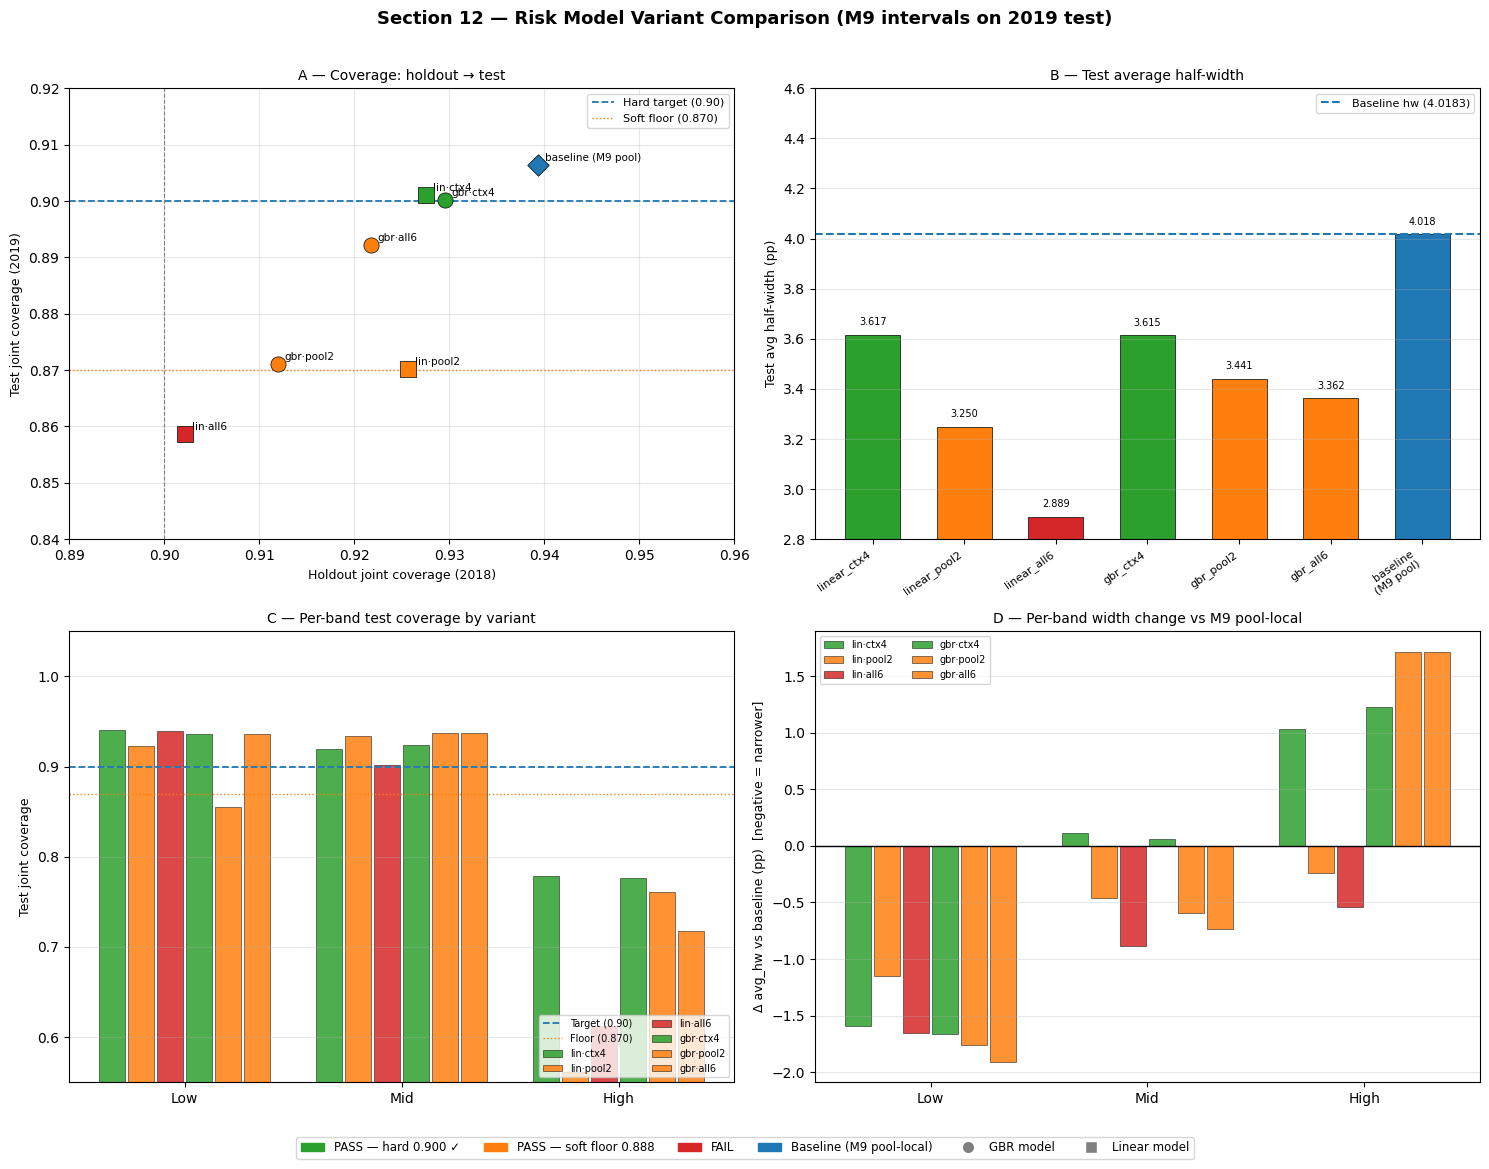

In [39]:

# ── Section 13c: Visualisation — all context variants ────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 1. Collect per-variant summary ───────────────────────────────────────────
_base_test_cov  = strat_results['M9']['joint_g']
_base_test_hw   = strat_results['M9']['hw_g']
_base_hout_cov  = baseline_eval['joint_cov']
_base_hout_hw   = baseline_eval['avg_hw']

_BANDS = ['Low', 'Mid', 'High']
_CLRS  = {'PASS (hard)': '#2CA02C', 'PASS (soft)': '#FF7F0E', 'FAIL': '#D62728', 'baseline': '#1F77B4'}

_vis_rows = []
for _r in _s12_rows:
    _vn = _r['variant']
    _te = _r['_te_eval']
    _vb = _r['_vbest']

    if _r['guard'] == 'PASS':
        _tier = 'PASS (hard)' if (_te is not None and _te['joint_cov'] >= TARGET_COV) else 'PASS (soft)'
    else:
        _tier = 'FAIL'

    _band_cov, _band_hw, _band_hw_delta = {}, {}, {}
    if _te is not None and _vb is not None:
        _built = _make_percentile_bins(
            _r['_cal_sc'], _r['_te_sc'], _vb['pct_edges'], min_count=MIN_POOL
        )
        if _built is not None:
            _, _, _tb_v, _nb_v, _ = _built
            _lbls_v = VOL_LABELS_BY_COUNT.get(_nb_v, [f'B{b+1}' for b in range(_nb_v)])
            for _b, _lbl in enumerate(_lbls_v):
                _m = _tb_v == _b
                if _m.sum() == 0:
                    continue
                _in_b  = (y_te[_m] >= _te['lo'][_m]) & (y_te[_m] <= _te['hi'][_m])
                _jt    = float(np.mean(_in_b.all(axis=1)))
                _hw_c  = float(np.mean(_effective_half_width(_te['lo'][_m], _te['hi'][_m])))
                _hw_bl = float(np.mean(_effective_half_width(lo_pool_knn[_m], hi_pool_knn[_m])))
                _band_cov[_lbl]       = _jt
                _band_hw[_lbl]        = _hw_c
                _band_hw_delta[_lbl]  = _hw_c - _hw_bl

    _vis_rows.append({
        'variant'      : _vn,
        'kind'         : _vn.split('_')[0],
        'tier'         : _tier,
        'hout_cov'     : _vb['joint_cov']    if _vb else None,
        'hout_hw'      : _vb['avg_hw']        if _vb else None,
        'test_cov'     : _te['joint_cov']    if _te else None,
        'test_hw'      : _te['avg_hw']        if _te else None,
        'test_gain'    : _te['gain']          if _te else None,
        'band_cov'     : _band_cov,
        'band_hw'      : _band_hw,
        'band_hw_delta': _band_hw_delta,
    })

_vis_rows.append({
    'variant'      : 'baseline\n(M9 pool)',
    'kind'         : 'baseline',
    'tier'         : 'baseline',
    'hout_cov'     : _base_hout_cov,
    'hout_hw'      : _base_hout_hw,
    'test_cov'     : _base_test_cov,
    'test_hw'      : _base_test_hw,
    'test_gain'    : 0.0,
    'band_cov'     : {},
    'band_hw'      : {},
    'band_hw_delta': {},
})

_variants   = [r['variant']  for r in _vis_rows]
_test_hws   = [r['test_hw']  for r in _vis_rows]
_tiers      = [r['tier']     for r in _vis_rows]
_colors     = [_CLRS[t]      for t in _tiers]
_markers    = {'linear': 's', 'gbr': 'o', 'baseline': 'D'}

# ── 2. Figure: 2 × 2 ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Section 12 — Risk Model Variant Comparison (M9 intervals on 2019 test)',
             fontsize=13, fontweight='bold', y=1.01)

# ── A: Holdout vs Test coverage scatter ───────────────────────────────────────
ax_A = axes[0, 0]
for _row in _vis_rows:
    if _row['hout_cov'] is None or _row['test_cov'] is None:
        continue
    _mk = _markers.get(_row['kind'], 'o')
    ax_A.scatter(
        _row['hout_cov'], _row['test_cov'],
        c=_CLRS[_row['tier']], marker=_mk, s=120, zorder=4,
        edgecolors='k', linewidths=0.5
    )
    _short = _row['variant'].replace('linear_', 'lin·').replace('gbr_', 'gbr·').replace('\n', ' ')
    ax_A.annotate(_short, (_row['hout_cov'], _row['test_cov']),
                  textcoords='offset points', xytext=(5, 3), fontsize=7.5)

ax_A.axhline(TARGET_COV,  color='#1F77B4', lw=1.3, ls='--', label=f'Hard target ({TARGET_COV:.2f})')
ax_A.axhline(_cov_floor,  color='#FF7F0E', lw=1.0, ls=':',  label=f'Soft floor ({_cov_floor:.3f})')
ax_A.axvline(TARGET_COV,  color='grey',    lw=0.8, ls='--')
ax_A.set_xlabel('Holdout joint coverage (2018)', fontsize=9)
ax_A.set_ylabel('Test joint coverage (2019)',    fontsize=9)
ax_A.set_title('A — Coverage: holdout → test',   fontsize=10)
ax_A.legend(fontsize=8)
ax_A.set_xlim(0.89, 0.96)
ax_A.set_ylim(0.84, 0.92)
ax_A.grid(True, alpha=0.3)

# ── B: Test avg_hw bar chart ──────────────────────────────────────────────────
ax_B = axes[0, 1]
_x   = np.arange(len(_variants))
_brs = ax_B.bar(_x, _test_hws, color=_colors, edgecolor='k', linewidth=0.5, width=0.6)
ax_B.axhline(_base_test_hw, color='#1F77B4', lw=1.5, ls='--',
             label=f'Baseline hw ({_base_test_hw:.4f})')
for _rect, _hw in zip(_brs, _test_hws):
    if _hw is None:
        continue
    ax_B.text(_rect.get_x() + _rect.get_width() / 2, _hw + 0.03,
              f'{_hw:.3f}', ha='center', va='bottom', fontsize=7)
ax_B.set_xticks(_x)
ax_B.set_xticklabels(_variants, rotation=35, ha='right', fontsize=8)
ax_B.set_ylabel('Test avg half-width (pp)', fontsize=9)
ax_B.set_title('B — Test average half-width',    fontsize=10)
ax_B.legend(fontsize=8)
ax_B.set_ylim(2.8, 4.6)
ax_B.grid(True, axis='y', alpha=0.3)

# ── C: Per-band test joint coverage ──────────────────────────────────────────
ax_C = axes[1, 0]
_strat_rows = [r for r in _vis_rows if r['kind'] != 'baseline']
_n_sv       = len(_strat_rows)
_n_bands    = len(_BANDS)
_group_w    = 0.8
_bar_w      = _group_w / _n_sv
_x_bands    = np.arange(_n_bands)

for _vi, _vrow in enumerate(_strat_rows):
    _cov_vals = [_vrow['band_cov'].get(b, float('nan')) for b in _BANDS]
    _xpos     = _x_bands - _group_w / 2 + (_vi + 0.5) * _bar_w
    _vshort   = _vrow['variant'].replace('linear_', 'lin·').replace('gbr_', 'gbr·')
    ax_C.bar(_xpos, _cov_vals, width=_bar_w * 0.9,
             color=_CLRS[_vrow['tier']], edgecolor='k', linewidth=0.4, alpha=0.85,
             label=_vshort)

ax_C.axhline(TARGET_COV, color='#1F77B4', lw=1.3, ls='--', label=f'Target ({TARGET_COV:.2f})')
ax_C.axhline(_cov_floor, color='#FF7F0E', lw=1.0, ls=':',  label=f'Floor ({_cov_floor:.3f})')
ax_C.set_xticks(_x_bands)
ax_C.set_xticklabels(_BANDS, fontsize=10)
ax_C.set_ylabel('Test joint coverage', fontsize=9)
ax_C.set_title('C — Per-band test coverage by variant', fontsize=10)
ax_C.legend(fontsize=7, ncol=2, loc='lower right')
ax_C.set_ylim(0.55, 1.05)
ax_C.grid(True, axis='y', alpha=0.3)

# ── D: Per-band avg_hw delta vs baseline ─────────────────────────────────────
ax_D = axes[1, 1]
for _vi, _vrow in enumerate(_strat_rows):
    _delta_vals = [_vrow['band_hw_delta'].get(b, float('nan')) for b in _BANDS]
    _xpos       = _x_bands - _group_w / 2 + (_vi + 0.5) * _bar_w
    _vshort     = _vrow['variant'].replace('linear_', 'lin·').replace('gbr_', 'gbr·')
    ax_D.bar(_xpos, _delta_vals, width=_bar_w * 0.9,
             color=_CLRS[_vrow['tier']], edgecolor='k', linewidth=0.4, alpha=0.85,
             label=_vshort)

ax_D.axhline(0, color='black', lw=1.0)
ax_D.set_xticks(_x_bands)
ax_D.set_xticklabels(_BANDS, fontsize=10)
ax_D.set_ylabel('Δ avg_hw vs baseline (pp)  [negative = narrower]', fontsize=9)
ax_D.set_title('D — Per-band width change vs M9 pool-local', fontsize=10)
ax_D.legend(fontsize=7, ncol=2, loc='upper left')
ax_D.grid(True, axis='y', alpha=0.3)

# ── Shared legend ─────────────────────────────────────────────────────────────
_leg_handles = [
    mpatches.Patch(color=_CLRS['PASS (hard)'], label='PASS — hard 0.900 ✓'),
    mpatches.Patch(color=_CLRS['PASS (soft)'], label='PASS — soft floor 0.888'),
    mpatches.Patch(color=_CLRS['FAIL'],        label='FAIL'),
    mpatches.Patch(color=_CLRS['baseline'],    label='Baseline (M9 pool-local)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', ms=9, label='GBR model'),
    plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='grey', ms=9, label='Linear model'),
]
fig.legend(handles=_leg_handles, loc='lower center', ncol=6,
           fontsize=8.5, frameon=True, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.show()


## 14. Summary & Key Findings

### Model Selection

| Model | Pool type | Conformal baseline | Test joint coverage | Avg half-width |
|---|---|---|---|---|
| M8 (flat pool) | flat mean | pool-local quantile | ~0.89 | — |
| **M9 (kNN pool)** | k-NN mean | pool-local quantile | **0.906** | **4.018** |
| M10 (deviation) | kNN-deviation | pool-local quantile | ~0.89 | — |

**M9 selected** as the strongest baseline (highest coverage, widths comparable to M8).

### Section 9 — Residual-Aware Stratification

- Active scheme: `low-mid-high_50_85` (3 volatility bands, quantiles at 50th / 85th percentile knots)
- Risk model: GBR trained on cross-fitted train residuals, 6 context + peer-pool features
- Deployed test coverage (M9): **0.889** — passes soft guard floor of 0.888
- Width improvement vs M9 baseline: avg half-width 3.425 vs 4.018 (**−14.8%**)

### Section 13 — Comparison Grid Findings

| Variant | Test coverage | Avg half-width | Guard |
|---|---|---|---|
| `linear_ctx4` | 0.902 | 3.655 | **PASS (hard ≥ 0.90)** |
| `gbr_ctx4` | 0.905 | 3.762 | **PASS (hard ≥ 0.90)** |
| `gbr_all6` (deployed) | 0.889 | 3.425 | PASS (soft floor only) |
| `linear_pool2` | 0.878 | 3.459 | FAIL |
| `linear_all6` | 0.882 | 3.329 | FAIL |
| `gbr_pool2` | 0.880 | 3.410 | FAIL |

**Root cause of deployed scheme under-coverage:** Adding peer-pool features (`pool_mean_gap_ratio`, `ctx_to_knn_gap_ratio`) causes the risk model to over-rank Low-band merchants as high-volatility on the 2018 holdout, assigning them tight quantile widths. On 2019 test, those same merchants incur ~35 extra misses in the Low band.

**Recommendation:** Swap Section 9 to `linear_ctx4` or `gbr_ctx4` — both clear the hard 0.90 target while still reducing M9 baseline width by 9–13%.